# 연고관광 통합 EDA

이 노트북은 `01_연고관광_EDA.ipynb`와 `01_고향관광_EDA_old.ipynb`의 검증된 분석을
`plans/active/연고관광_통합_EDA_계획.md` 및 `docs/project/ANALYSIS_CONTRACT.md`에 맞게
통합한다. 원본 두 노트북과 `data/` 원자료는 수정하지 않는다.

분석 원칙은 다음과 같다.

- 시장 규모는 응답자 행의 `SA1_1`~`SA1_5 × WT_DOM`으로 추정한다.
- 행태 분석은 6개 여행 슬롯에서 `CASE`가 존재하는 28,564개 여행을 사용한다.
- A-series 상세 비교는 CASE 1 대 CASE 2로 제한한다. CASE 3의 A-series는 구조적 비해당이다.
- CASE 2 대 CASE 3은 `D_TRA*` 공통 변수만 비교하며, 차이를 정책 효과나 인과로 표현하지 않는다.
- 비가중 N, 가중 추정치, 분모, 결측 수를 함께 제시한다. 층화·PSU 정보 부재로 완전한
  복합표본 분산을 재현할 수 없으므로 불확실성은 Kish 유효표본크기 기반 근사치로 표시한다.
- 첫 번째 방문지 기록은 주목적지나 실제 이동순서를 뜻하지 않는다.

난수 시드: `20260713`

In [1]:
from pathlib import Path
import sys


current_directory = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in (current_directory, *current_directory.parents)
        if (candidate / "src" / "path.py").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "프로젝트 루트를 찾을 수 없습니다. 프로젝트 내부에서 실행하세요."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.path import (  # noqa: E402
    NOTEBOOKS_DIR,
    OUTPUTS_DIR,
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR,
    PROJECT_ROOT,
    RAW_DATA_DIR,
)


ROOT = PROJECT_ROOT

## 0. 환경·입력·재현성 검증

In [2]:
import hashlib
import json
import os
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
from IPython.display import Markdown, display

SEED = 20260713
RNG = np.random.default_rng(SEED)
ROOT = PROJECT_ROOT
SAV_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "y2025"
    / "2025년_국민여행조사_국내여행.SAV"
)
CODEBOOK_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "y2025"
    / "national_travel_survey_codebook_2025.csv"
)
REGION_PATH = (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR
    / "national_travel_survey_region_code.csv"
)
DECLINE_PATH = RAW_DATA_DIR / "pop_decline_danger" / "pop_decline_danger_region.csv"

for path in (SAV_PATH, CODEBOOK_PATH, REGION_PATH, DECLINE_PATH):
    assert path.exists(), f"입력 파일 없음: {path}"

plt.rcParams.update({
    "figure.facecolor": "#FCFCFB",
    "axes.facecolor": "#FCFCFB",
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
CASE_COLORS = {1: "#0072B2", 2: "#D55E00", 3: "#E69F00"}
CASE_LABELS = {
    1: "CASE 1 관광·휴양",
    2: "CASE 2 관광결합 연고방문",
    3: "CASE 3 단순 연고방문",
    4: "CASE 4 기타",
    5: "CASE 5 비관광 기타",
}




def short_case_label(case):
    """Return a compact label for one travel type.

    Args:
        case: Integer travel type.

    Returns:
        Compact Korean display label.
    """
    return {1: "CASE 1 관광", 2: "CASE 2 연고관광", 3: "CASE 3 단순방문"}[case]


def file_sha256(path):
    """Calculate a file SHA-256 digest.

    Args:
        path: File path to hash.

    Returns:
        Lowercase hexadecimal digest.
    """
    digest = hashlib.sha256()
    with Path(path).open("rb") as file_handle:
        for chunk in iter(lambda: file_handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


environment = pd.Series({
    "python": sys.version.split()[0],
    "executable": sys.executable,
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "pyreadstat": pyreadstat.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "seed": SEED,
})
input_register = pd.DataFrame([
    {
        "file": str(path.relative_to(ROOT)),
        "modified": pd.Timestamp(path.stat().st_mtime, unit="s"),
        "sha256": file_sha256(path),
    }
    for path in (SAV_PATH, CODEBOOK_PATH, REGION_PATH, DECLINE_PATH)
])
display(environment.to_frame("value"), input_register)

,value
python,3.13.14
executable,C:\Users\ilove\OneDrive\Desktop\tourism_poster...
platform,Windows-11-10.0.26200-SP0
pandas,3.0.3
numpy,2.4.6
pyreadstat,1.3.5
matplotlib,3.11.0
seed,20260713


,file,modified,sha256
0,data\raw\national_travel_survey\y2025\2025년_국민...,2026-07-19 19:29:06.330578327,e367c69415ee99171f2114e6fdcd28e50b440384f93a9a...
1,data\raw\national_travel_survey\y2025\national...,2026-07-10 14:04:11.000000000,d877caa999dd11f76694229237a1a85f682d750a6b0744...
2,data\raw\national_travel_survey\national_trave...,2026-07-10 14:04:10.000000000,da82de139b59683f29125801080d4cc462f278fa4bf840...
3,data\raw\pop_decline_danger\pop_decline_danger...,2026-07-10 14:04:10.000000000,27483a801ca76eeab730e2b9101926531297824a676297...


In [3]:
df, meta = pyreadstat.read_sav(str(SAV_PATH))
codebook = pd.read_csv(CODEBOOK_PATH, encoding="utf-8-sig")
allowed_columns = set(codebook["col_name"])

assert df.shape == (52185, 2419), df.shape
assert df["ID"].is_unique
assert df["WT_DOM"].notna().all()
assert (df["WT_DOM"] > 0).all()


def var_labels(metadata, column):
    """Return stripped SPSS value labels for one variable.

    Args:
        metadata: Metadata returned by ``pyreadstat.read_sav``.
        column: SPSS variable name.

    Returns:
        A mapping from stored codes to normalized labels.
    """
    assert column in allowed_columns, column
    raw_labels = metadata.variable_value_labels.get(column, {})
    return {
        key: value.strip() if isinstance(value, str) else value
        for key, value in raw_labels.items()
    }


raw_age_labels = meta.variable_value_labels.get("BAGE", {})
age_labels = var_labels(meta, "BAGE")
expected_age_labels = {
    "15~19세", "20대", "30대", "40대", "50대", "60대", "70세이상"
}
assert set(age_labels.values()) == expected_age_labels
assert len(age_labels.values()) == len(set(age_labels.values()))
assert all(label and label == label.strip() for label in age_labels.values())
assert set(df.loc[df["BAGE"].notna(), "BAGE"]) <= set(age_labels)

label_changes = pd.DataFrame([
    {"code": key, "raw": repr(value), "normalized": age_labels[key]}
    for key, value in raw_age_labels.items()
    if value != age_labels[key]
])
weight_summary = df["WT_DOM"].describe(
    percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]
).to_frame("WT_DOM")
display(
    pd.Series({"rows": len(df), "columns": df.shape[1], "unique_ID": df["ID"].nunique()}),
    label_changes,
    weight_summary,
)

rows         52185
columns       2419
unique_ID    52185
dtype: int64

,code,raw,normalized
0,1.0,' 15~19세',15~19세
1,2.0,' 20대',20대
2,3.0,' 30대',30대
3,4.0,' 40대',40대
4,5.0,' 50대',50대
5,6.0,' 60대',60대
6,7.0,' 70세이상',70세이상


,WT_DOM
count,52185.000000
mean,10675.733947
std,7153.016579
min,129.048066
1%,1287.707358
10%,3201.731727
50%,8917.626967
90%,20404.177561
99%,32686.121360
max,71809.794635


## 1. 설문 분기와 분석 단위 검증

In [4]:
trip_fields = {
    "CHECK": "CHECK",
    "CASE": "CASE",
    "SMONTH": "SMONTH",
    "S_Day": "NIGHTS",
    "COST": "COST",
    "NUM": "NUM",
    "ONE_COST": "ONE_COST",
    "1_SPOT": "FIRST_SPOT",
    "1_Q6": "FIRST_Q6",
}
respondent_fields = [
    "ID", "WT_DOM", "BAGE", "BSEX", "BARA", "BMAR", "BFAM", "DQ7"
]
trip_frames = []
for trip_no in range(1, 7):
    source_columns = respondent_fields + [
        f"D_TRA{trip_no}_{source}" for source in trip_fields
    ]
    frame = df[source_columns].copy()
    frame.columns = respondent_fields + list(trip_fields.values())
    frame["TRIP_NO"] = trip_no
    trip_frames.append(frame)

trip_slots = pd.concat(trip_frames, ignore_index=True)
core_columns = ["SMONTH", "NIGHTS", "COST", "NUM", "ONE_COST", "FIRST_SPOT"]
case_missing_with_data = trip_slots["CASE"].isna() & trip_slots[core_columns].notna().any(axis=1)
trips_long = trip_slots.loc[trip_slots["CASE"].notna()].copy()
trips_long["CASE"] = trips_long["CASE"].astype(int)
trips_long["is_yeongo"] = trips_long["CASE"].isin([2, 3])
trips_long["is_combined_yeongo"] = trips_long["CASE"].eq(2)
trips_long["is_simple_yeongo"] = trips_long["CASE"].eq(3)
trips_long["is_overnight"] = trips_long["NIGHTS"].ge(1)
trips_long["companion_proxy"] = trips_long["NUM"] - 1

assert not case_missing_with_data.any()
assert not trips_long.duplicated(["ID", "TRIP_NO"]).any()
assert len(trips_long) == 28564
assert trips_long["ID"].nunique() == 26838
assert (trips_long.groupby("ID").size() >= 2).sum() == 1605
assert trips_long[core_columns].notna().all().all()
assert (trips_long["companion_proxy"] >= 0).all()

slot_diagnostics = pd.DataFrame({
    "CASE_nonmissing": [df[f"D_TRA{i}_CASE"].notna().sum() for i in range(1, 7)],
    "CHECK_Y": [df[f"D_TRA{i}_CHECK"].eq("Y").sum() for i in range(1, 7)],
}, index=pd.Index(range(1, 7), name="TRIP_NO"))
case_completeness = trips_long.groupby("CASE")[core_columns].agg(
    lambda series: series.notna().mean() * 100
)
unit_contract = pd.DataFrame([
    {"unit": "응답자/조사회차", "key": "ID", "rows": len(df)},
    {"unit": "개별 여행", "key": "ID + TRIP_NO", "rows": len(trips_long)},
])
display(unit_contract, slot_diagnostics, case_completeness)

,unit,key,rows
0,응답자/조사회차,ID,52185
1,개별 여행,ID + TRIP_NO,28564


,CASE_nonmissing,CHECK_Y
TRIP_NO,,
1,26713,22729
2,1723,1178
3,114,73
4,10,5
5,3,2
6,1,1


,SMONTH,NIGHTS,COST,NUM,ONE_COST,FIRST_SPOT
CASE,,,,,,
1,100.0,100.0,100.0,100.0,100.0,100.0
2,100.0,100.0,100.0,100.0,100.0,100.0
3,100.0,100.0,100.0,100.0,100.0,100.0
4,100.0,100.0,100.0,100.0,100.0,100.0
5,100.0,100.0,100.0,100.0,100.0,100.0


In [5]:
visit_frames = []
for trip_no in range(1, 7):
    for spot_no in range(1, 6):
        spot_column = f"D_TRA{trip_no}_{spot_no}_SPOT"
        visit = df[["ID", "WT_DOM", spot_column]].copy()
        visit.columns = ["ID", "WT_DOM", "SPOT"]
        visit["TRIP_NO"] = trip_no
        visit["SPOT_NO"] = spot_no
        visit_frames.append(visit)

visits_long = pd.concat(visit_frames, ignore_index=True).dropna(subset=["SPOT"])
visits_long = visits_long.merge(
    trips_long[["ID", "TRIP_NO", "CASE"]],
    on=["ID", "TRIP_NO"],
    how="inner",
    validate="many_to_one",
)
assert not visits_long.duplicated(["ID", "TRIP_NO", "SPOT_NO"]).any()

region_codes = pd.read_csv(REGION_PATH, encoding="utf-8-sig")
region_codes["SPOT"] = (
    region_codes["시도_코드"].astype(int) * 1000
    + region_codes["시군구_코드"].astype(int)
).astype(float)
region_lookup = region_codes[["SPOT", "시도명", "시군구명"]].drop_duplicates("SPOT")
visits_long = visits_long.merge(region_lookup, on="SPOT", how="left", validate="many_to_one")
mapping_failures = visits_long.loc[
    visits_long["시도명"].isna(), "SPOT"
].value_counts().rename_axis("SPOT").to_frame("N")
assert mapping_failures.empty, mapping_failures.head(20)

first_visits = visits_long.loc[visits_long["SPOT_NO"].eq(1)].copy()
assert len(first_visits) == len(trips_long)
display(
    pd.Series({
        "trips_long_rows": len(trips_long),
        "trips_long_IDs": trips_long["ID"].nunique(),
        "repeat_trip_IDs": (trips_long.groupby("ID").size() >= 2).sum(),
        "visits_long_rows": len(visits_long),
        "visit_mapping_failures": len(mapping_failures),
    }).to_frame("value"),
    visits_long.groupby("SPOT_NO").size().rename("N").to_frame(),
)

,value
trips_long_rows,28564
trips_long_IDs,26838
repeat_trip_IDs,1605
visits_long_rows,47398
visit_mapping_failures,0


,N
SPOT_NO,
1,28564
2,10426
3,4870
4,2342
5,1196


,A2_1,A3_1,A4_1,A5_1,A5A_1,A6,A7_TOTAL,A8,A9,A10,A11,A12_1,NA8
D_TRA1_CASE,,,,,,,,,,,,,
CASE 1 관광·휴양,32.4,100.0,80.4,100.0,27.7,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
CASE 2 관광결합 연고방문,8.2,100.0,68.6,100.0,10.3,100.0,100.0,100.0,100.0,100.0,100.0,99.9,100.0
CASE 3 단순 연고방문,3.6,11.1,9.1,11.1,3.3,11.1,11.1,11.1,11.1,11.1,11.1,11.1,11.1
CASE 4 기타,27.8,100.0,52.8,100.0,18.3,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
CASE 5 비관광 기타,5.2,15.2,12.5,15.2,4.2,15.2,15.2,15.2,15.2,15.2,15.2,15.2,15.2


,raw_N,clean_N,clean_ZQ1_response_pct
D_TRA1_CASE,,,
CASE 3 단순 연고방문,2503,2226,99.0
CASE 5 비관광 기타,690,585,99.5


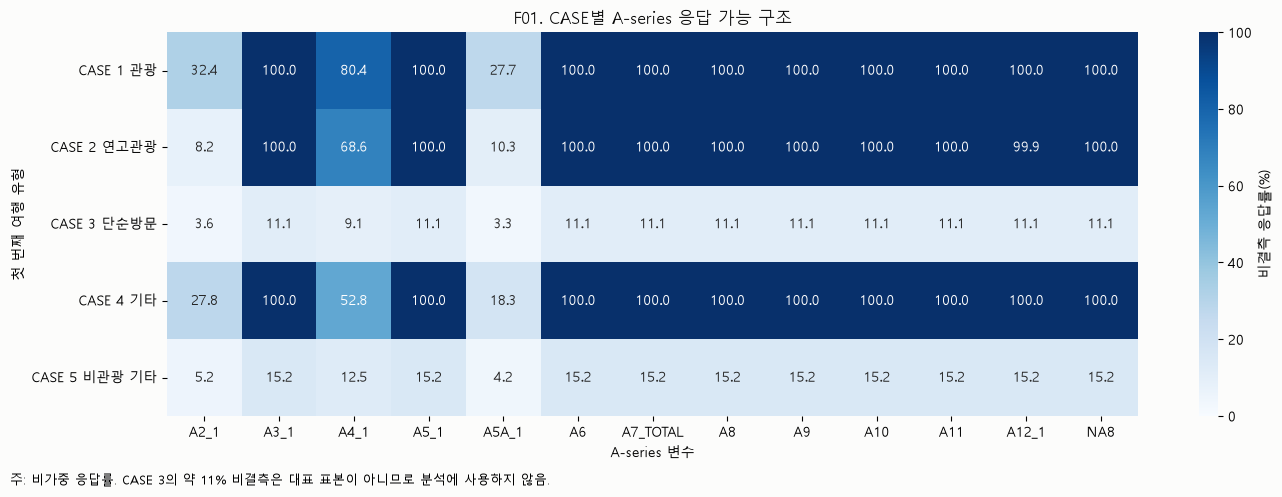

In [6]:
a_response_columns = [
    "A2_1", "A3_1", "A4_1", "A5_1", "A5A_1", "A6",
    "A7_TOTAL", "A8", "A9", "A10", "A11", "A12_1", "NA8",
]
assert not set(a_response_columns) - allowed_columns
branch_rates = df.groupby("D_TRA1_CASE")[a_response_columns].agg(
    lambda series: series.notna().mean() * 100
).round(1)

# 분석용 A-series 표본은 CASE 1과 CASE 2뿐이다. CASE 3은 아래 분기 진단에만 등장한다.
a_analysis = df.loc[df["D_TRA1_CASE"].isin([1, 2])].copy()
assert set(a_analysis["D_TRA1_CASE"].dropna().astype(int).unique()) == {1, 2}
assert not a_analysis["D_TRA1_CASE"].eq(3).any()

case_matrix = pd.DataFrame({
    f"CASE_{trip_no}": df[f"D_TRA{trip_no}_CASE"]
    for trip_no in range(1, 7)
})
has_tourism_trip = case_matrix.isin([1, 2, 4]).any(axis=1)
zq1_raw = df.loc[df["D_TRA1_CASE"].isin([3, 5])].copy()
zq1_clean = zq1_raw.loc[~has_tourism_trip.loc[zq1_raw.index]].copy()
zq1_diagnostic = pd.DataFrame({
    "raw_N": zq1_raw.groupby("D_TRA1_CASE").size(),
    "clean_N": zq1_clean.groupby("D_TRA1_CASE").size(),
    "clean_ZQ1_response_pct": zq1_clean.groupby("D_TRA1_CASE")["ZQ1_1"].apply(
        lambda series: series.notna().mean() * 100
    ),
}).rename(index=CASE_LABELS)

assert len(zq1_raw) == 3193
assert len(zq1_clean) == 2811
assert len(zq1_clean.loc[zq1_clean["D_TRA1_CASE"].eq(3)]) == 2226
display(branch_rates.rename(index=CASE_LABELS), zq1_diagnostic.round(1))

fig, ax = plt.subplots(figsize=(14, 4.8))
heatmap_data = branch_rates.rename(index={
    case: short_case_label(int(case)) if int(case) in (1, 2, 3) else CASE_LABELS[int(case)]
    for case in branch_rates.index
})
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    cbar_kws={"label": "비결측 응답률(%)"},
    ax=ax,
)
ax.set(
    title="F01. CASE별 A-series 응답 가능 구조",
    xlabel="A-series 변수",
    ylabel="첫 번째 여행 유형",
)
fig.text(
    0.01,
    -0.02,
    "주: 비가중 응답률. CASE 3의 약 11% 비결측은 대표 표본이 아니므로 분석에 사용하지 않음.",
    fontsize=9,
)
plt.tight_layout()
plt.show()

분기 판정: CASE 3의 A9·NA8 비결측은 대표적인 CASE 3 응답이 아니다. 따라서 이후 A-series
분석 객체 `a_analysis`에는 CASE 1·2만 들어가며, CASE 2·3 비교에는 `trips_long`의 공통 변수만
사용한다. ZQ1은 특정 여행의 원인이 아니라, 같은 조사기간 관광·휴양여행이 없었던 응답자의
응답자 수준 보조 진단으로만 해석한다.

## 2. 공통 가중 통계 함수와 시장 규모

,weighted_trips,share_pct
CASE 1 관광·휴양,217286531.0,72.21
CASE 2 관광결합 연고방문,37525420.0,12.47
CASE 3 단순 연고방문,32351011.0,10.75
CASE 4 기타,6486739.0,2.16
CASE 5 비관광 기타,7259606.0,2.41


,value
official_SA1_relationship_share_pct,23.222
long_behavior_check_share_pct,23.222
difference_percentage_points,0.000


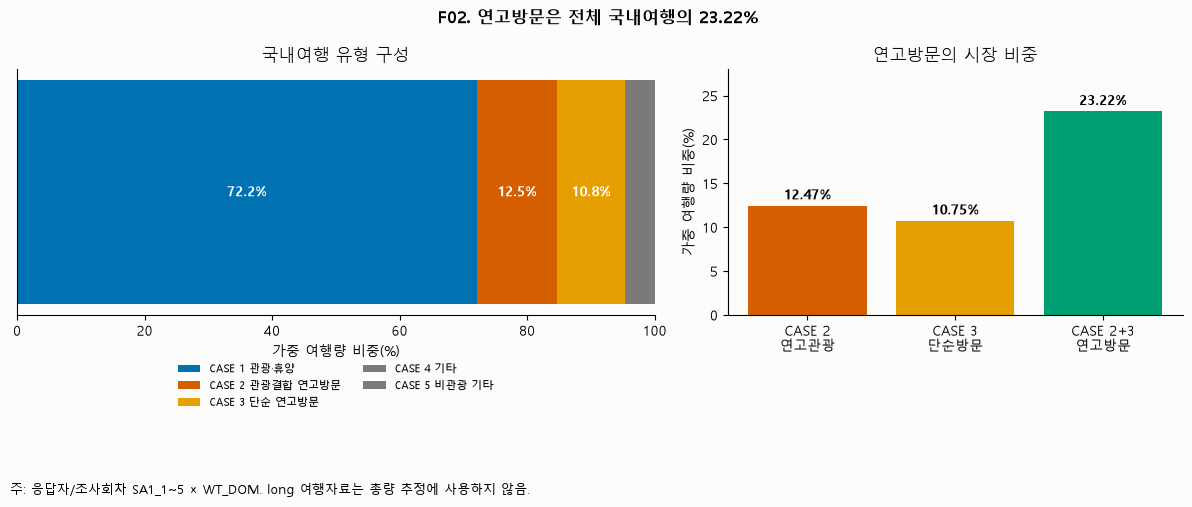


**결과 해석.** 연고방문(CASE 2+3)은 2025년 국내여행 가중 여행량의 **23.22%**다.
CASE 2와 CASE 3을 합친 조작적 정의이므로 고향 방문이나 관계의 지속기간을 직접 뜻하지는 않지만,
별도 정책 질문을 검토할 만한 규모임은 확인된다. 이 수치는 이후 행태 분석의 long 자료가 아니라
응답자 수준 여행횟수 문항으로 계산했다.


In [7]:
def weighted_mean(values, weights):
    """Return a weighted mean after pairwise missing-value removal.

    Args:
        values: Numeric observations.
        weights: Positive survey weights.

    Returns:
        Weighted arithmetic mean.
    """
    valid = pd.Series(values).notna() & pd.Series(weights).notna()
    value_array = np.asarray(values)[valid]
    weight_array = np.asarray(weights)[valid]
    return np.average(value_array, weights=weight_array)


def weighted_quantile(values, weights, probabilities):
    """Calculate deterministic weighted quantiles.

    Args:
        values: Numeric observations.
        weights: Positive survey weights.
        probabilities: Quantiles between zero and one.

    Returns:
        An array of weighted quantiles.
    """
    frame = pd.DataFrame({"value": values, "weight": weights}).dropna()
    frame = frame.sort_values("value")
    cumulative = frame["weight"].cumsum() - frame["weight"] / 2
    cumulative = cumulative / frame["weight"].sum()
    return np.interp(probabilities, cumulative, frame["value"])


def effective_n(weights):
    """Calculate Kish effective sample size.

    Args:
        weights: Positive survey weights.

    Returns:
        Kish effective sample size.
    """
    weight_array = np.asarray(pd.Series(weights).dropna(), dtype=float)
    return weight_array.sum() ** 2 / np.square(weight_array).sum()


def weighted_binary_summary(data, indicator, weight="WT_DOM"):
    """Summarize a binary outcome with an approximate 95% interval.

    Args:
        data: Source data frame.
        indicator: Boolean or zero-one column name.
        weight: Survey weight column name.

    Returns:
        A series with N, denominator, percent, N_eff, and interval.
    """
    valid = data[[indicator, weight]].dropna()
    proportion = weighted_mean(valid[indicator].astype(float), valid[weight])
    n_eff = effective_n(valid[weight])
    standard_error = np.sqrt(proportion * (1 - proportion) / n_eff)
    return pd.Series({
        "N": len(valid),
        "missing_N": len(data) - len(valid),
        "weighted_denominator": valid[weight].sum(),
        "percent": proportion * 100,
        "N_eff": n_eff,
        "ci_low": max(0.0, proportion - 1.96 * standard_error) * 100,
        "ci_high": min(1.0, proportion + 1.96 * standard_error) * 100,
    })


def weighted_multiselect_table(data, columns, label_column, group="D_TRA1_CASE"):
    """Summarize slot-form multiple responses by analysis group.

    Args:
        data: Eligible A-series records.
        columns: Ordered response-slot columns.
        label_column: Column whose value labels define response categories.
        group: Group column.

    Returns:
        Long table of weighted selection percentages.
    """
    labels = var_labels(meta, label_column)
    rows = []
    for group_value, frame in data.groupby(group):
        denominator = frame["WT_DOM"].sum()
        slot_values = frame[columns]
        for code_value, response in labels.items():
            selected = slot_values.eq(code_value).any(axis=1)
            rows.append({
                "group": CASE_LABELS[int(group_value)],
                "code": int(code_value),
                "response": response,
                "N": len(frame),
                "missing_or_unselected_N": int((~selected).sum()),
                "weighted_denominator": denominator,
                "N_eff": effective_n(frame["WT_DOM"]),
                "weighted_selection_pct": (
                    frame.loc[selected, "WT_DOM"].sum() / denominator * 100
                ),
            })
    result = pd.DataFrame(rows)
    expected = set(int(value) for value in labels)
    assert set(result["code"]) == expected
    assert result.groupby("group")["response"].nunique().eq(len(labels)).all()
    return result


def add_value_labels(axis, decimals=1, suffix=""):
    """Add compact labels to horizontal bar containers.

    Args:
        axis: Matplotlib axis containing horizontal bars.
        decimals: Number of decimal places.
        suffix: Text appended to each value.
    """
    for container in axis.containers:
        axis.bar_label(
            container,
            fmt=f"%.{decimals}f{suffix}",
            padding=3,
            fontsize=8,
        )


sa_columns = [f"SA1_{case}" for case in range(1, 6)]
weighted_trip_volume = pd.Series({
    case: (df[f"SA1_{case}"] * df["WT_DOM"]).sum()
    for case in range(1, 6)
}, name="weighted_trips")
market_table = weighted_trip_volume.to_frame()
market_table["share_pct"] = market_table["weighted_trips"] / market_table["weighted_trips"].sum() * 100
market_table.index = market_table.index.map(CASE_LABELS)
relationship_share = (
    weighted_trip_volume.loc[[2, 3]].sum() / weighted_trip_volume.sum() * 100
)
long_share_check = weighted_mean(
    trips_long["is_yeongo"].astype(float), trips_long["WT_DOM"]
) * 100
assert abs(relationship_share - 23.22) < 0.02
display(
    market_table.round({"weighted_trips": 0, "share_pct": 2}),
    pd.Series({
        "official_SA1_relationship_share_pct": relationship_share,
        "long_behavior_check_share_pct": long_share_check,
        "difference_percentage_points": long_share_check - relationship_share,
    }).to_frame("value").round(3),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.4, 1]})
shares = market_table["share_pct"].to_numpy()
colors = [CASE_COLORS.get(case, "#7A7A7A") for case in range(1, 6)]
left = 0.0
for case, share, color in zip(range(1, 6), shares, colors):
    axes[0].barh([0], [share], left=left, color=color, label=CASE_LABELS[case])
    if share >= 4:
        axes[0].text(left + share / 2, 0, f"{share:.1f}%", ha="center", va="center", color="white", fontweight="bold")
    left += share
axes[0].set(title="국내여행 유형 구성", xlabel="가중 여행량 비중(%)", yticks=[])
axes[0].set_xlim(0, 100)
axes[0].legend(frameon=False, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=2)
axes[1].bar(
    ["CASE 2\n연고관광", "CASE 3\n단순방문", "CASE 2+3\n연고방문"],
    [market_table.iloc[1]["share_pct"], market_table.iloc[2]["share_pct"], relationship_share],
    color=[CASE_COLORS[2], CASE_COLORS[3], "#009E73"],
)
axes[1].set(title="연고방문의 시장 비중", ylabel="가중 여행량 비중(%)", ylim=(0, 28))
for patch, value in zip(axes[1].patches, [market_table.iloc[1]["share_pct"], market_table.iloc[2]["share_pct"], relationship_share]):
    axes[1].text(patch.get_x() + patch.get_width() / 2, value + 0.7, f"{value:.2f}%", ha="center", fontweight="bold")
fig.suptitle("F02. 연고방문은 전체 국내여행의 23.22%", fontweight="bold")
fig.text(0.01, -0.03, "주: 응답자/조사회차 SA1_1~5 × WT_DOM. long 여행자료는 총량 추정에 사용하지 않음.", fontsize=9)
plt.tight_layout()
plt.show()

display(Markdown(f"""
**결과 해석.** 연고방문(CASE 2+3)은 2025년 국내여행 가중 여행량의 **{relationship_share:.2f}%**다.
CASE 2와 CASE 3을 합친 조작적 정의이므로 고향 방문이나 관계의 지속기간을 직접 뜻하지는 않지만,
별도 정책 질문을 검토할 만한 규모임은 확인된다. 이 수치는 이후 행태 분석의 long 자료가 아니라
응답자 수준 여행횟수 문항으로 계산했다.
"""))

시장 규모의 공식 값은 `SA1_* × WT_DOM`이다. long 자료는 한 응답자의 여러 여행마다 `WT_DOM`이
반복되므로 총량 추정에 쓰지 않고 행태 분포와 검산에만 쓴다. 두 값의 작은 차이는 분석 단위와
조사 문항 집계방식 차이이며 임의로 일치시키지 않는다.

## 3. CASE 1·2·3 전반 행태와 CASE 2·3 공통 변수 비교

,N,weighted_denominator,N_eff,ONE_COST_missing_N,weighted_ONE_COST_mean,weighted_ONE_COST_p10,weighted_ONE_COST_median,weighted_ONE_COST_p90,weighted_NUM_mean,weighted_NIGHTS_mean,weighted_overnight_pct,weighted_female_pct,weighted_age_70_plus_pct,weighted_capital_resident_pct
group,,,,,,,,,,,,,,
CASE 1 관광·휴양,20206,217286531.0,14131.1,0,143302.1,37500.0,95000.0,300000.0,2.5,0.5,38.5,52.4,7.6,51.4
CASE 2 관광결합 연고방문,3977,37525420.5,2711.1,0,115250.8,37500.0,86667.7,210000.0,2.6,0.9,61.8,54.2,11.4,38.1
CASE 3 단순 연고방문,2902,32351010.5,2062.4,0,73339.0,20000.0,50000.0,150000.0,2.3,0.6,41.5,51.8,11.3,60.7


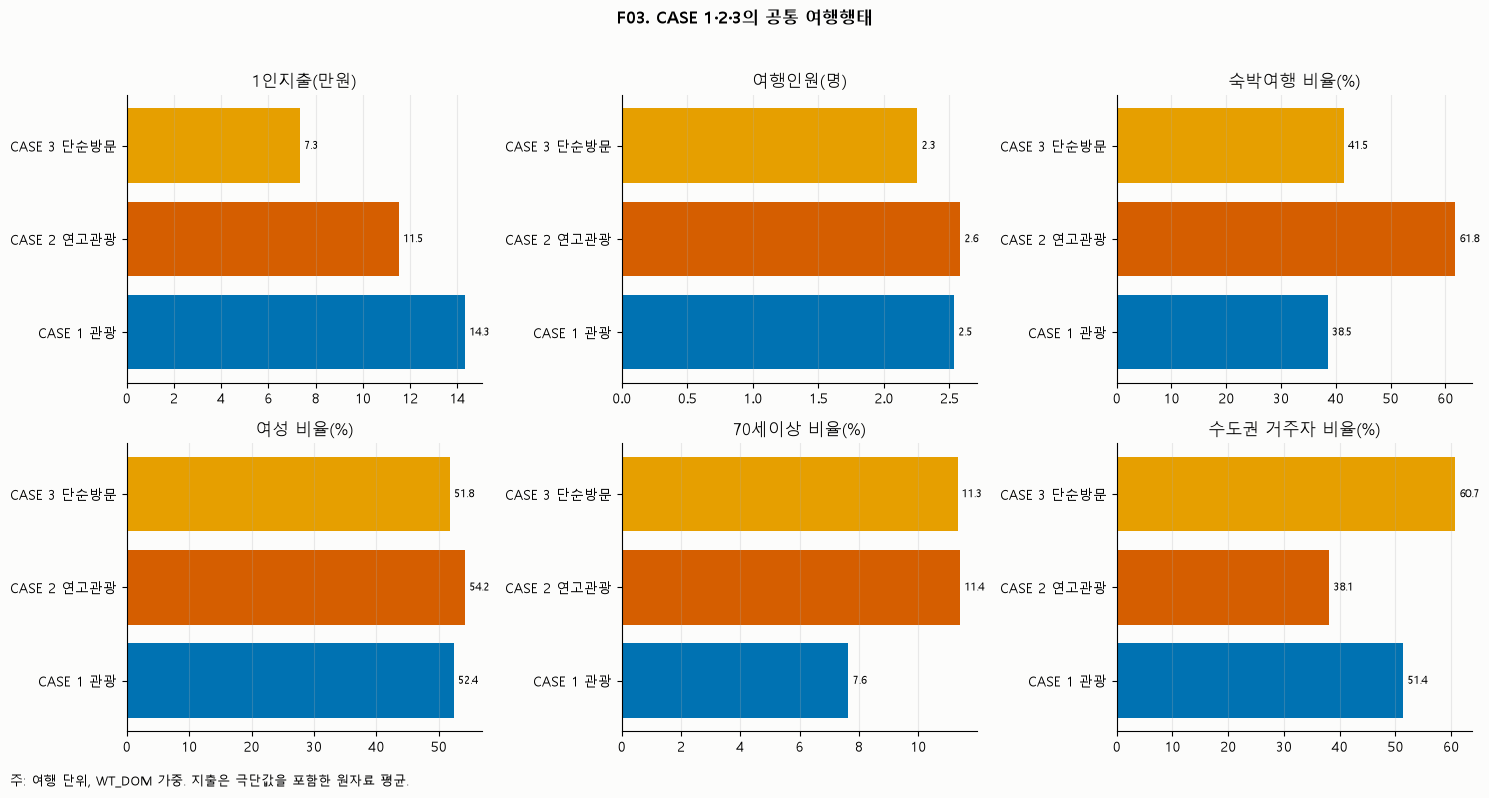

In [8]:
trips_long["female"] = trips_long["BSEX"].eq(2)
trips_long["age_70_plus"] = trips_long["BAGE"].eq(7)
trips_long["capital_resident"] = trips_long["BARA"].isin([1, 4, 9])
common_rows = []
for case in (1, 2, 3):
    group = trips_long.loc[trips_long["CASE"].eq(case)]
    q10, median, q90 = weighted_quantile(
        group["ONE_COST"], group["WT_DOM"], [0.1, 0.5, 0.9]
    )
    common_rows.append({
        "group": CASE_LABELS[case],
        "N": len(group),
        "weighted_denominator": group["WT_DOM"].sum(),
        "N_eff": effective_n(group["WT_DOM"]),
        "ONE_COST_missing_N": group["ONE_COST"].isna().sum(),
        "weighted_ONE_COST_mean": weighted_mean(group["ONE_COST"], group["WT_DOM"]),
        "weighted_ONE_COST_p10": q10,
        "weighted_ONE_COST_median": median,
        "weighted_ONE_COST_p90": q90,
        "weighted_NUM_mean": weighted_mean(group["NUM"], group["WT_DOM"]),
        "weighted_NIGHTS_mean": weighted_mean(group["NIGHTS"], group["WT_DOM"]),
        "weighted_overnight_pct": weighted_mean(group["is_overnight"], group["WT_DOM"]) * 100,
        "weighted_female_pct": weighted_mean(group["female"], group["WT_DOM"]) * 100,
        "weighted_age_70_plus_pct": weighted_mean(group["age_70_plus"], group["WT_DOM"]) * 100,
        "weighted_capital_resident_pct": weighted_mean(group["capital_resident"], group["WT_DOM"]) * 100,
    })
common_summary = pd.DataFrame(common_rows).set_index("group")
display(common_summary.round(1))

profile_metrics = [
    ("weighted_ONE_COST_mean", "1인지출(만원)", 1 / 10000),
    ("weighted_NUM_mean", "여행인원(명)", 1),
    ("weighted_overnight_pct", "숙박여행 비율(%)", 1),
    ("weighted_female_pct", "여성 비율(%)", 1),
    ("weighted_age_70_plus_pct", "70세이상 비율(%)", 1),
    ("weighted_capital_resident_pct", "수도권 거주자 비율(%)", 1),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, (column, title, scale) in zip(axes.flat, profile_metrics):
    values = common_summary[column] * scale
    axis.barh(
        [short_case_label(case) for case in (1, 2, 3)],
        [values.loc[CASE_LABELS[case]] for case in (1, 2, 3)],
        color=[CASE_COLORS[case] for case in (1, 2, 3)],
    )
    axis.set_title(title)
    axis.grid(axis="x", alpha=0.25)
    add_value_labels(axis, decimals=1)
fig.suptitle("F03. CASE 1·2·3의 공통 여행행태", fontweight="bold")
fig.text(0.01, 0.01, "주: 여행 단위, WT_DOM 가중. 지출은 극단값을 포함한 원자료 평균.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
plt.show()

N  missing_N  weighted_denominator  \
group            specification                                                
CASE 2 관광결합 연고방문 ONE_COST           3977.0        0.0           37525420.50   
                 ONE_COST_winsor99  3977.0        0.0           37525420.50   
                 log1p_ONE_COST     3977.0        0.0           37525420.50   
CASE 3 단순 연고방문   ONE_COST           2902.0        0.0           32351010.52   
                 ONE_COST_winsor99  2902.0        0.0           32351010.52   
                 log1p_ONE_COST     2902.0        0.0           32351010.52   

                                         mean    N_eff     ci_low    ci_high  
group            specification                                                
CASE 2 관광결합 연고방문 ONE_COST           115250.85  2711.10  111154.52  119347.18  
                 ONE_COST_winsor99  112850.35  2711.10  109384.10  116316.59  
                 log1p_ONE_COST         11.38  2711.10      11.35      11.41  
CASE 3 단순 연고방문   ONE_COST            73338.96  2062.42   69659.25   77018.67  
                 ONE_COST_winsor99   71554.98  2062.42   68998.85   74111.10  
                 log1p_ONE_COST         10.90  2062.42      10.86      10.93

,value
weighted_mean_difference_CASE2_minus_CASE3_won,41911.887
weighted_mean_ratio_CASE2_over_CASE3,1.571


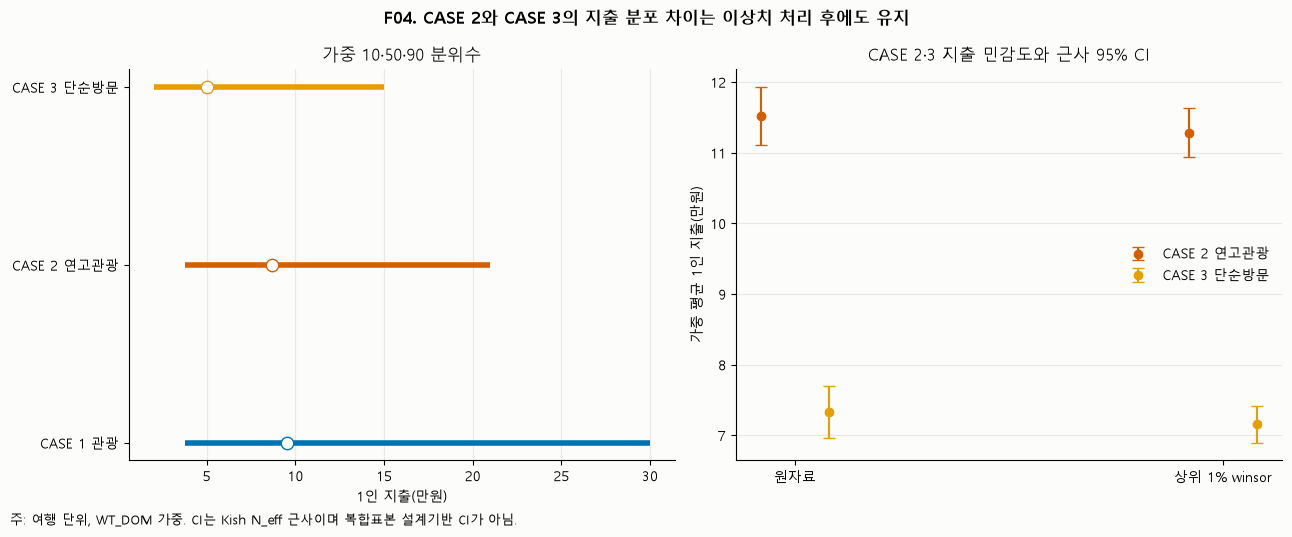


**결과 해석.** CASE 2의 가중 1인 지출 평균은 **115,251원**,
CASE 3은 **73,339원**으로 차이는
**41,912원**이다. 상위 1% winsor와 로그 사양에서도 방향이 유지되지만, 이는 서로 다른
여행유형의 횡단면 차이다. CASE 3을 CASE 2로 바꾸면 동일 금액이 증가한다는 정책효과로 읽을 수 없다.


In [9]:
def weighted_mean_interval(data, value, weight="WT_DOM"):
    """Estimate a weighted mean and Kish-based approximate interval.

    Args:
        data: Source data frame.
        value: Numeric value column.
        weight: Survey weight column.

    Returns:
        A series containing the mean, effective N, and 95% interval.
    """
    valid = data[[value, weight]].dropna()
    mean = weighted_mean(valid[value], valid[weight])
    n_eff = effective_n(valid[weight])
    variance = np.average((valid[value] - mean) ** 2, weights=valid[weight])
    standard_error = np.sqrt(variance / n_eff)
    return pd.Series({
        "N": len(valid),
        "missing_N": len(data) - len(valid),
        "weighted_denominator": valid[weight].sum(),
        "mean": mean,
        "N_eff": n_eff,
        "ci_low": mean - 1.96 * standard_error,
        "ci_high": mean + 1.96 * standard_error,
    })


spending_rows = []
for case in (2, 3):
    group = trips_long.loc[trips_long["CASE"].eq(case)].copy()
    cap = group["ONE_COST"].quantile(0.99)
    group["ONE_COST_winsor99"] = group["ONE_COST"].clip(upper=cap)
    group["log1p_ONE_COST"] = np.log1p(group["ONE_COST"])
    for specification in ("ONE_COST", "ONE_COST_winsor99", "log1p_ONE_COST"):
        result = weighted_mean_interval(group, specification)
        result["group"] = CASE_LABELS[case]
        result["specification"] = specification
        spending_rows.append(result)
spending_sensitivity = pd.DataFrame(spending_rows).set_index(["group", "specification"])

raw_difference = (
    spending_sensitivity.loc[(CASE_LABELS[2], "ONE_COST"), "mean"]
    - spending_sensitivity.loc[(CASE_LABELS[3], "ONE_COST"), "mean"]
)
raw_ratio = (
    spending_sensitivity.loc[(CASE_LABELS[2], "ONE_COST"), "mean"]
    / spending_sensitivity.loc[(CASE_LABELS[3], "ONE_COST"), "mean"]
)
display(
    spending_sensitivity.round(2),
    pd.Series({
        "weighted_mean_difference_CASE2_minus_CASE3_won": raw_difference,
        "weighted_mean_ratio_CASE2_over_CASE3": raw_ratio,
    }).to_frame("value").round(3),
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
for y_pos, case in enumerate((1, 2, 3)):
    row = common_summary.loc[CASE_LABELS[case]]
    axes[0].hlines(
        y_pos,
        row["weighted_ONE_COST_p10"] / 10000,
        row["weighted_ONE_COST_p90"] / 10000,
        color=CASE_COLORS[case],
        linewidth=4,
    )
    axes[0].scatter(row["weighted_ONE_COST_median"] / 10000, y_pos, color="white", edgecolor=CASE_COLORS[case], s=80, zorder=3)
axes[0].set(
    title="가중 10·50·90 분위수",
    xlabel="1인 지출(만원)",
    yticks=range(3),
    yticklabels=[short_case_label(case) for case in (1, 2, 3)],
)
axes[0].grid(axis="x", alpha=0.25)

spec_labels = {"ONE_COST": "원자료", "ONE_COST_winsor99": "상위 1% winsor"}
for x_pos, specification in enumerate(spec_labels):
    for offset, case in [(-0.08, 2), (0.08, 3)]:
        row = spending_sensitivity.loc[(CASE_LABELS[case], specification)]
        axes[1].errorbar(
            x_pos + offset,
            row["mean"] / 10000,
            yerr=[[row["mean"] / 10000 - row["ci_low"] / 10000], [row["ci_high"] / 10000 - row["mean"] / 10000]],
            fmt="o",
            color=CASE_COLORS[case],
            capsize=4,
            label=short_case_label(case) if x_pos == 0 else None,
        )
axes[1].set(
    title="CASE 2·3 지출 민감도와 근사 95% CI",
    ylabel="가중 평균 1인 지출(만원)",
    xticks=range(2),
    xticklabels=list(spec_labels.values()),
)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.25)
fig.suptitle("F04. CASE 2와 CASE 3의 지출 분포 차이는 이상치 처리 후에도 유지", fontweight="bold")
fig.text(0.01, -0.01, "주: 여행 단위, WT_DOM 가중. CI는 Kish N_eff 근사이며 복합표본 설계기반 CI가 아님.", fontsize=9)
plt.tight_layout()
plt.show()

display(Markdown(f"""
**결과 해석.** CASE 2의 가중 1인 지출 평균은 **{spending_sensitivity.loc[(CASE_LABELS[2], 'ONE_COST'), 'mean']:,.0f}원**,
CASE 3은 **{spending_sensitivity.loc[(CASE_LABELS[3], 'ONE_COST'), 'mean']:,.0f}원**으로 차이는
**{raw_difference:,.0f}원**이다. 상위 1% winsor와 로그 사양에서도 방향이 유지되지만, 이는 서로 다른
여행유형의 횡단면 차이다. CASE 3을 CASE 2로 바꾸면 동일 금액이 증가한다는 정책효과로 읽을 수 없다.
"""))

CASE 2와 CASE 3의 지출·동반·숙박 차이는 서로 다른 여행유형 사이의 **가중 기술적 차이**다.
동일인의 정책 전후 비교가 아니므로 “전환 시 증가분”, “효과”, “원인”으로 해석하지 않는다.
지출은 원자료, 상위 1% winsor, `log1p`를 나란히 두어 극단값 민감도를 확인한다.

### 3.1 지출·숙박 누수 진단

,N_all,weighted_denominator_all,N_eff_all,overnight_pct,overnight_ci_low,overnight_ci_high,N_overnight,weighted_denominator_overnight,N_eff_overnight,family_house_among_overnight_pct,family_house_ci_low,family_house_ci_high
group,,,,,,,,,,,,
CASE 1 관광·휴양,20206,217286531.0,14131.1,38.5,37.7,39.3,7691,83641057.1,5317.3,2.5,2.1,2.9
CASE 2 관광결합 연고방문,3977,37525420.5,2711.1,61.8,60.0,63.6,2424,23186822.6,1662.9,74.9,72.8,77.0
CASE 3 단순 연고방문,2902,32351010.5,2062.4,41.5,39.4,43.6,1329,13420034.8,912.4,96.5,95.3,97.7


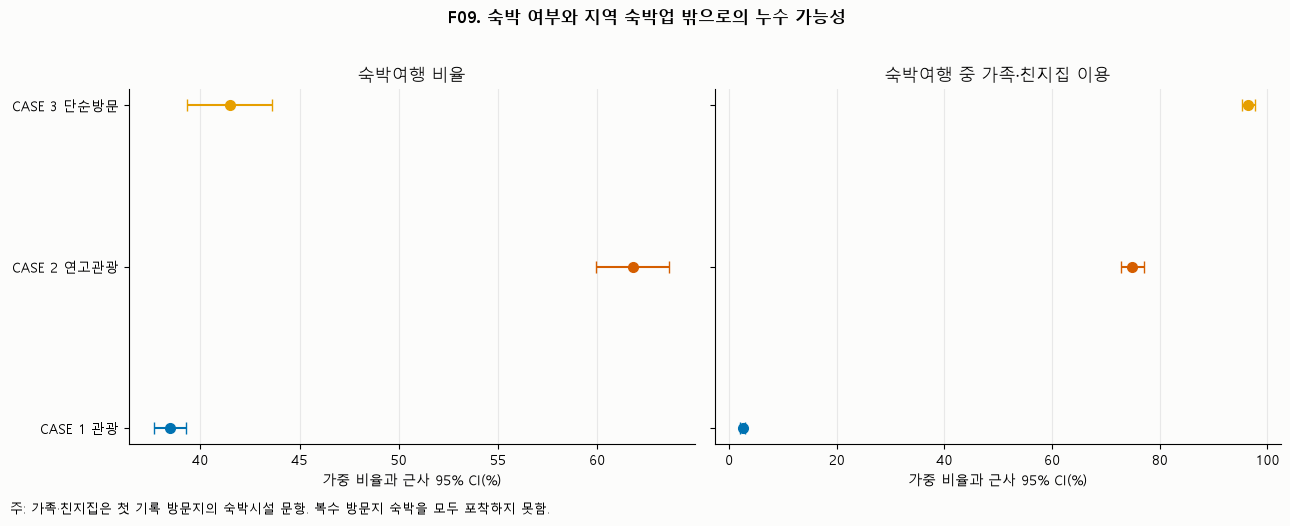


**결과 해석.** CASE 2의 숙박여행 비율은 **61.8%**,
CASE 3은 **41.5%**다. 숙박여행 가운데 가족·친지집
이용이 높으면 숙박 자체가 지역 숙박업 매출로 이어지지 않을 수 있다. 다만 첫 기록 방문지의 숙박시설만
사용하므로 이를 정확한 지역 외부 누수액으로 환산하지 않는다.


In [10]:
lodging_rows = []
for case in (1, 2, 3):
    group = trips_long.loc[trips_long["CASE"].eq(case)].copy()
    overnight = group.loc[group["is_overnight"]].copy()
    overnight["family_house"] = overnight["FIRST_Q6"].eq(12)
    overnight_summary = weighted_binary_summary(group, "is_overnight")
    family_summary = weighted_binary_summary(overnight, "family_house")
    lodging_rows.append({
        "group": CASE_LABELS[case],
        "N_all": len(group),
        "weighted_denominator_all": group["WT_DOM"].sum(),
        "N_eff_all": effective_n(group["WT_DOM"]),
        "overnight_pct": overnight_summary["percent"],
        "overnight_ci_low": overnight_summary["ci_low"],
        "overnight_ci_high": overnight_summary["ci_high"],
        "N_overnight": len(overnight),
        "weighted_denominator_overnight": overnight["WT_DOM"].sum(),
        "N_eff_overnight": effective_n(overnight["WT_DOM"]),
        "family_house_among_overnight_pct": family_summary["percent"],
        "family_house_ci_low": family_summary["ci_low"],
        "family_house_ci_high": family_summary["ci_high"],
    })
lodging_summary = pd.DataFrame(lodging_rows).set_index("group")
display(lodging_summary.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
for axis, column, low, high, title in [
    (axes[0], "overnight_pct", "overnight_ci_low", "overnight_ci_high", "숙박여행 비율"),
    (axes[1], "family_house_among_overnight_pct", "family_house_ci_low", "family_house_ci_high", "숙박여행 중 가족·친지집 이용"),
]:
    for y_pos, case in enumerate((1, 2, 3)):
        row = lodging_summary.loc[CASE_LABELS[case]]
        axis.errorbar(
            row[column], y_pos,
            xerr=[[row[column] - row[low]], [row[high] - row[column]]],
            fmt="o", color=CASE_COLORS[case], capsize=4, markersize=7,
        )
    axis.set(title=title, xlabel="가중 비율과 근사 95% CI(%)", yticks=range(3), yticklabels=[short_case_label(case) for case in (1, 2, 3)])
    axis.grid(axis="x", alpha=0.25)
fig.suptitle("F09. 숙박 여부와 지역 숙박업 밖으로의 누수 가능성", fontweight="bold")
fig.text(0.01, 0.01, "주: 가족·친지집은 첫 기록 방문지의 숙박시설 문항. 복수 방문지 숙박을 모두 포착하지 못함.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
plt.show()

display(Markdown(f"""
**결과 해석.** CASE 2의 숙박여행 비율은 **{lodging_summary.loc[CASE_LABELS[2], 'overnight_pct']:.1f}%**,
CASE 3은 **{lodging_summary.loc[CASE_LABELS[3], 'overnight_pct']:.1f}%**다. 숙박여행 가운데 가족·친지집
이용이 높으면 숙박 자체가 지역 숙박업 매출로 이어지지 않을 수 있다. 다만 첫 기록 방문지의 숙박시설만
사용하므로 이를 정확한 지역 외부 누수액으로 환산하지 않는다.
"""))

## 4. CASE 1 대 CASE 2 A-series 상세 비교

,group,response,N,missing_N,weighted_denominator,weighted_pct
6,CASE 1 관광·휴양,과거 방문 경험,19048,0,204988717.3,35.5
4,CASE 1 관광·휴양,주변인(친지/친구/동료 등),19048,0,204988717.3,28.5
0,CASE 1 관광·휴양,인터넷 사이트/모바일 앱(PC/스마트폰),19048,0,204988717.3,18.8
7,CASE 1 관광·휴양,정보 없이 방문,19048,0,204988717.3,9.7
2,CASE 1 관광·휴양,광고(TV/라디오/신문/잡지/지하철/옥외광고판 등),19048,0,204988717.3,2.9
1,CASE 1 관광·휴양,기사 및 방송 프로그램(TV/라디오/신문/잡지),19048,0,204988717.3,2.5
3,CASE 1 관광·휴양,"여행사(방문, 전화)",19048,0,204988717.3,1.2
5,CASE 1 관광·휴양,관광 안내 서적,19048,0,204988717.3,0.9
15,CASE 2 관광결합 연고방문,과거 방문 경험,3844,1,36389140.4,46.7
13,CASE 2 관광결합 연고방문,주변인(친지/친구/동료 등),3844,1,36389140.4,23.0


,group,response,N,missing_N,weighted_denominator,weighted_pct
0,CASE 1 관광·휴양,"인터넷/웹사이트 커뮤니티 게시판 (네이버 블로그, 다음 카페 등)",3265,0,38506327.7,49.1
4,CASE 1 관광·휴양,"SNS(인스타그램, 페이스북 등)",3265,0,38506327.7,13.8
5,CASE 1 관광·휴양,동영상 사이트(유튜브 등),3265,0,38506327.7,12.3
1,CASE 1 관광·휴양,인터넷/웹사이트 지도/평가 정보,3265,0,38506327.7,10.0
2,CASE 1 관광·휴양,인터넷/웹사이트 여행 관련 (신문)기사/컬럼,3265,0,38506327.7,5.1
3,CASE 1 관광·휴양,여행 및 숙박 전문 사이트 또는 앱,3265,0,38506327.7,5.0
6,CASE 1 관광·휴양,"대화형 인공지능서비스(챗GPT, 뤼튼 등)",3265,0,38506327.7,1.7
8,CASE 1 관광·휴양,공공기관 홈페이지,3265,0,38506327.7,1.1
10,CASE 2 관광결합 연고방문,"인터넷/웹사이트 커뮤니티 게시판 (네이버 블로그, 다음 카페 등)",211,0,2091763.7,51.5
14,CASE 2 관광결합 연고방문,"SNS(인스타그램, 페이스북 등)",211,0,2091763.7,12.5


N  missing_N  weighted_denominator  \
group            variable                                             
CASE 1 관광·휴양     A6        19048.0        0.0          2.049887e+08   
                 A9        19048.0        0.0          2.049887e+08   
                 A10       19048.0        0.0          2.049887e+08   
                 NA8       19048.0        0.0          2.049887e+08   
CASE 2 관광결합 연고방문 A6         3844.0        1.0          3.638914e+07   
                 A9         3844.0        1.0          3.638914e+07   
                 A10        3844.0        1.0          3.638914e+07   
                 NA8        3844.0        1.0          3.638914e+07   

                                mean     N_eff     ci_low    ci_high  
group            variable                                             
CASE 1 관광·휴양     A6             3.82  13314.76       3.75       3.89  
                 A9             4.22  13314.76       4.21       4.22  
                 A10            4.09  13314.76       4.08       4.10  
                 NA8       139773.43  13314.76  137155.60  142391.27  
CASE 2 관광결합 연고방문 A6             3.11   2621.72       3.05       3.16  
                 A9             4.22   2621.72       4.20       4.24  
                 A10            4.11   2621.72       4.10       4.13  
                 NA8       110680.50   2621.72  106759.18  114601.82

,value
pure_type_1_N,18776
pure_type_2_N,3731


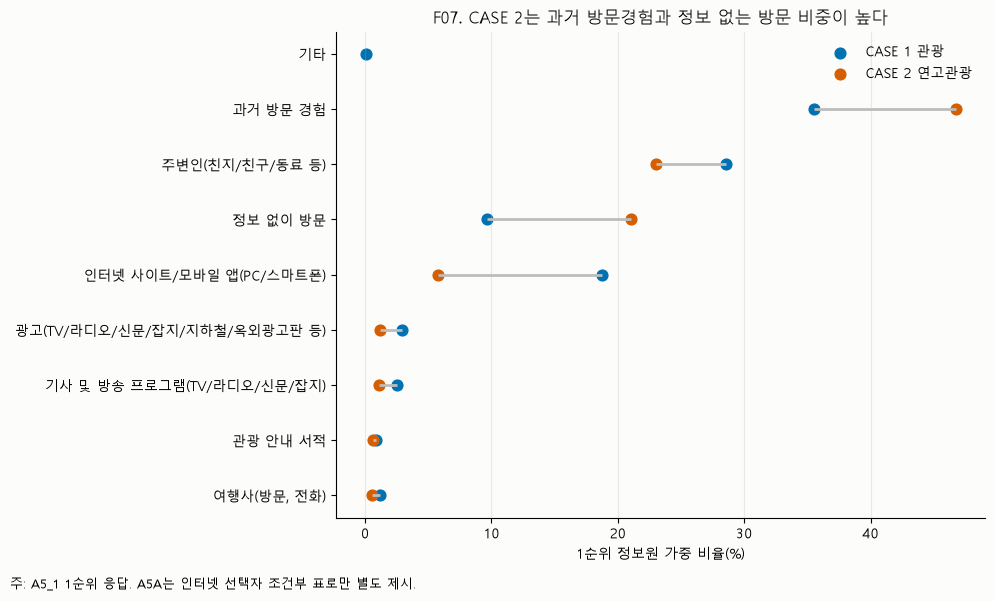

**읽는 법.** A5는 1순위 정보원이며 A5A는 A5에서 인터넷을 고른 응답자만의 조건부 문항이다. CASE 2에서 과거 방문경험·주변인·정보 없이 방문의 비중이 크다면 신규 광고보다 기존 관계망에 지역 식음·체험 정보를 얹는 전달경로가 더 직접적일 수 있다. 다만 채널 차이가 정책 반응의 인과효과를 뜻하지 않는다.

In [11]:
def weighted_category_table(data, column, group="D_TRA1_CASE", condition=None):
    """Build a weighted categorical distribution with denominators.

    Args:
        data: A-series eligible data frame.
        column: Categorical response column.
        group: Grouping column.
        condition: Optional Boolean mask evaluated on ``data``.

    Returns:
        Long-form weighted percentage table.
    """
    source = data.loc[condition].copy() if condition is not None else data.copy()
    labels = var_labels(meta, column)
    rows = []
    for group_value, frame in source.groupby(group):
        valid = frame[[column, "WT_DOM"]].dropna()
        denominator = valid["WT_DOM"].sum()
        counts = valid.groupby(column)["WT_DOM"].sum()
        for response, weighted_count in counts.items():
            rows.append({
                "group": CASE_LABELS[int(group_value)],
                "response": labels.get(response, str(response)),
                "N": len(valid),
                "missing_N": len(frame) - len(valid),
                "weighted_denominator": denominator,
                "weighted_pct": weighted_count / denominator * 100,
            })
    return pd.DataFrame(rows)


information_channels = weighted_category_table(a_analysis, "A5_1")
internet_condition = a_analysis["A5_1"].eq(1)
internet_channels = weighted_category_table(
    a_analysis, "A5A_1", condition=internet_condition
)

a_metrics = []
for case in (1, 2):
    group = a_analysis.loc[a_analysis["D_TRA1_CASE"].eq(case)]
    for variable in ("A6", "A9", "A10", "NA8"):
        result = weighted_mean_interval(group, variable)
        result["group"] = CASE_LABELS[case]
        result["variable"] = variable
        a_metrics.append(result)
a_series_summary = pd.DataFrame(a_metrics).set_index(["group", "variable"])

other_sa_type_1 = ["SA1_2", "SA1_3", "SA1_4", "SA1_5"]
other_sa_type_2 = ["SA1_1", "SA1_3", "SA1_4", "SA1_5"]
pure_type_1 = a_analysis["D_TRA1_CASE"].eq(1) & a_analysis[other_sa_type_1].fillna(0).eq(0).all(axis=1)
pure_type_2 = a_analysis["D_TRA1_CASE"].eq(2) & a_analysis[other_sa_type_2].fillna(0).eq(0).all(axis=1)
pure_counts = pd.Series({
    "pure_type_1_N": int(pure_type_1.sum()),
    "pure_type_2_N": int(pure_type_2.sum()),
})

display(
    information_channels.sort_values(["group", "weighted_pct"], ascending=[True, False]).groupby("group").head(8).round(1),
    internet_channels.sort_values(["group", "weighted_pct"], ascending=[True, False]).groupby("group").head(8).round(1),
    a_series_summary.round(2),
    pure_counts.to_frame("value"),
)

channel_pivot = information_channels.pivot(
    index="response", columns="group", values="weighted_pct"
).sort_values(CASE_LABELS[2])
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(channel_pivot))
ax.hlines(y, channel_pivot[CASE_LABELS[1]], channel_pivot[CASE_LABELS[2]], color="#BDBDBD", linewidth=2)
ax.scatter(channel_pivot[CASE_LABELS[1]], y, color=CASE_COLORS[1], s=60, label=short_case_label(1))
ax.scatter(channel_pivot[CASE_LABELS[2]], y, color=CASE_COLORS[2], s=60, label=short_case_label(2))
ax.set(
    title="F07. CASE 2는 과거 방문경험과 정보 없는 방문 비중이 높다",
    xlabel="1순위 정보원 가중 비율(%)",
    yticks=y,
    yticklabels=channel_pivot.index,
)
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)
fig.text(0.01, 0.01, "주: A5_1 1순위 응답. A5A는 인터넷 선택자 조건부 표로만 별도 제시.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

display(Markdown(
    "**읽는 법.** A5는 1순위 정보원이며 A5A는 A5에서 인터넷을 고른 응답자만의 조건부 문항이다. "
    "CASE 2에서 과거 방문경험·주변인·정보 없이 방문의 비중이 크다면 신규 광고보다 기존 관계망에 "
    "지역 식음·체험 정보를 얹는 전달경로가 더 직접적일 수 있다. 다만 채널 차이가 정책 반응의 인과효과를 뜻하지 않는다."
))

,group,code,response,N,missing_or_unselected_N,weighted_denominator,N_eff,weighted_selection_pct
10,CASE 1 관광·휴양,11,사전 예약하지 않았다,19048,7186,204988717.3,13314.8,61.3
0,CASE 1 관광·휴양,1,"숙박시설(호텔, 콘도미니엄/리조트, 펜션, 유스호스텔 등)",19048,12885,204988717.3,13314.8,33.0
2,CASE 1 관광·휴양,3,"교통수단(항공, 선박, 철도, 버스 등)",19048,17718,204988717.3,13314.8,7.2
3,CASE 1 관광·휴양,4,차량대여/렌트,19048,18361,204988717.3,13314.8,3.7
5,CASE 1 관광·휴양,6,"레저시설(놀이시설, 스파, 스키장, 골프장 등)",19048,18596,204988717.3,13314.8,2.9
1,CASE 1 관광·휴양,2,식당,19048,18737,204988717.3,13314.8,1.6
4,CASE 1 관광·휴양,5,"관광명소(유적지, 국립공원 등)",19048,18910,204988717.3,13314.8,0.9
6,CASE 1 관광·휴양,7,"체험 프로그램(농어촌 체험, 생태체험 학습 등)",19048,18948,204988717.3,13314.8,0.6
21,CASE 2 관광결합 연고방문,11,사전 예약하지 않았다,3845,628,36402984.3,2622.7,83.5
11,CASE 2 관광결합 연고방문,1,"숙박시설(호텔, 콘도미니엄/리조트, 펜션, 유스호스텔 등)",3845,3530,36402984.3,2622.7,8.5


,group,response,N,missing_N,weighted_denominator,weighted_pct
0,CASE 1 관광·휴양,여행지 지명도,19048,0,204988717.3,19.5
1,CASE 1 관광·휴양,볼거리 제공,19048,0,204988717.3,18.3
4,CASE 1 관광·휴양,여행할 수 있는 시간,19048,0,204988717.3,13.0
13,CASE 1 관광·휴양,여행 동반자 유형,19048,0,204988717.3,11.0
3,CASE 1 관광·휴양,이동 거리,19048,0,204988717.3,10.7
7,CASE 1 관광·휴양,음식,19048,0,204988717.3,8.3
2,CASE 1 관광·휴양,저렴한 여행경비,19048,0,204988717.3,4.7
10,CASE 1 관광·휴양,경험자의 추천,19048,0,204988717.3,3.2
19,CASE 2 관광결합 연고방문,여행할 수 있는 시간,3844,1,36389140.4,15.4
15,CASE 2 관광결합 연고방문,여행지 지명도,3844,1,36389140.4,14.0


,group,code,response,N,missing_or_unselected_N,weighted_denominator,N_eff,weighted_selection_pct
0,CASE 1 관광·휴양,1,자연 및 풍경감상,19048,3740,204988717.3,13314.8,79.4
1,CASE 1 관광·휴양,2,음식관광(지역 맛집 등),19048,6197,204988717.3,13314.8,67.2
5,CASE 1 관광·휴양,6,휴식/휴양,19048,8288,204988717.3,13314.8,56.8
3,CASE 1 관광·휴양,4,역사 유적지 방문,19048,16896,204988717.3,13314.8,10.8
4,CASE 1 관광·휴양,5,"테마파크, 놀이시설, 동/식물원 방문",19048,17253,204988717.3,13314.8,9.8
2,CASE 1 관광·휴양,3,"야외 위락 및 스포츠, 레포츠 활동",19048,17508,204988717.3,13314.8,8.7
7,CASE 1 관광·휴양,8,쇼핑,19048,17595,204988717.3,13314.8,7.4
14,CASE 1 관광·휴양,15,시티투어,19048,17958,204988717.3,13314.8,5.9
8,CASE 1 관광·휴양,9,지역 문화예술/공연/전시시설 관람,19048,18065,204988717.3,13314.8,4.9
10,CASE 1 관광·휴양,11,지역 축제/이벤트 참가,19048,18336,204988717.3,13314.8,3.5


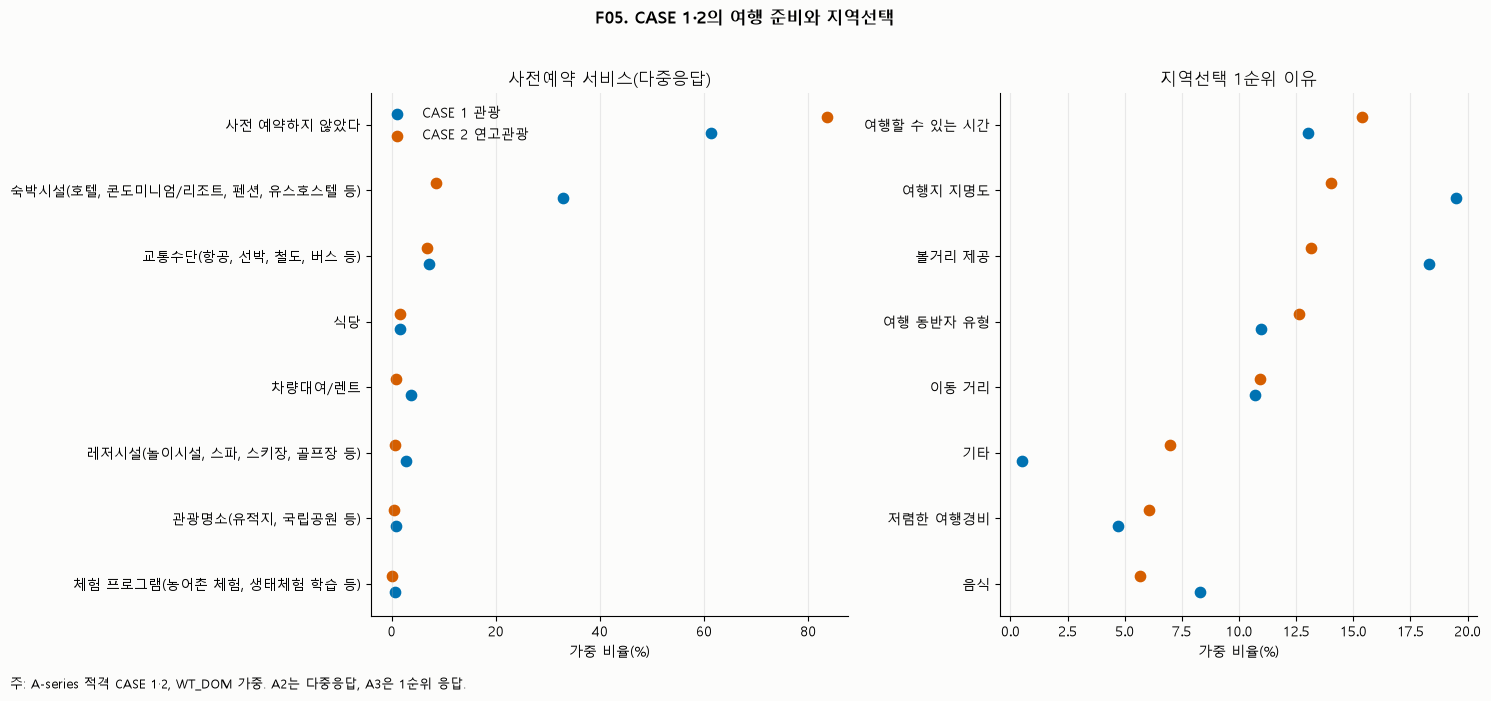

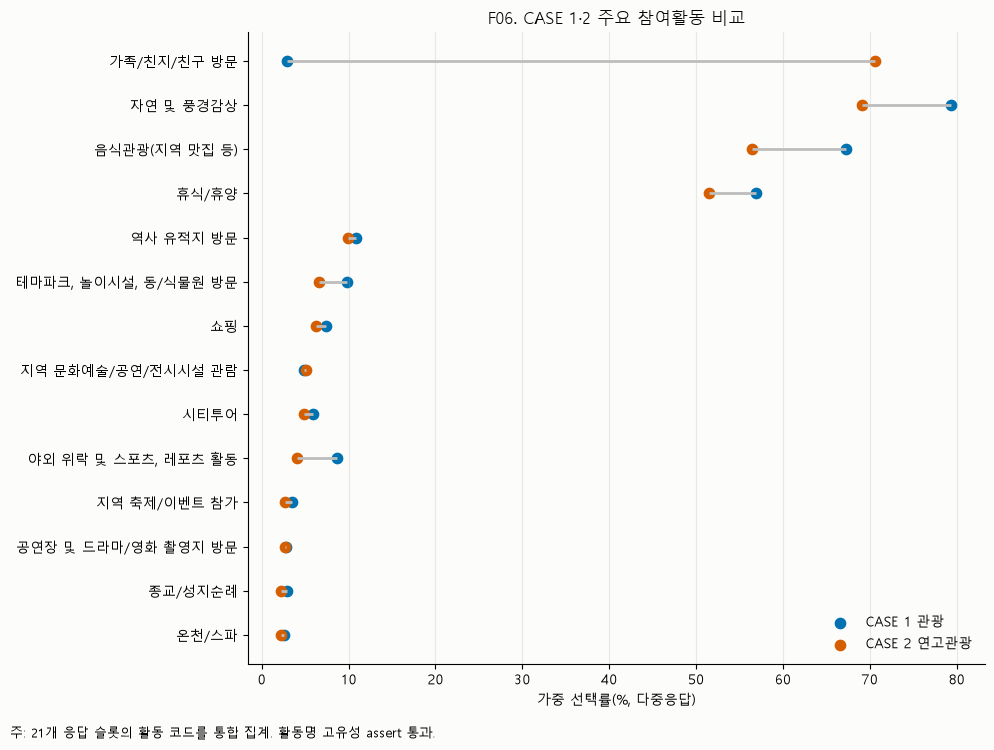

In [12]:
def slot_order(column):
    """Extract the numeric suffix used to order response slots."""
    return int(column.rsplit("_", maxsplit=1)[1])


reservation_columns = sorted(
    [column for column in df.columns if column.startswith("A2_")], key=slot_order
)
activity_columns = sorted(
    [column for column in df.columns if column.startswith("A4_")], key=slot_order
)
reservation_table = weighted_multiselect_table(
    a_analysis, reservation_columns, "A2_1"
)
activity_table = weighted_multiselect_table(a_analysis, activity_columns, "A4_1")
reason_table = weighted_category_table(a_analysis, "A3_1")

assert activity_table["response"].nunique() == 21
assert reservation_table["response"].nunique() == 11
assert not activity_table["response"].duplicated().all()

display(
    reservation_table.sort_values(
        ["group", "weighted_selection_pct"], ascending=[True, False]
    ).groupby("group").head(8).round(1),
    reason_table.sort_values(
        ["group", "weighted_pct"], ascending=[True, False]
    ).groupby("group").head(8).round(1),
    activity_table.sort_values(
        ["group", "weighted_selection_pct"], ascending=[True, False]
    ).groupby("group").head(12).round(1),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for axis, source, value, title in [
    (axes[0], reservation_table, "weighted_selection_pct", "사전예약 서비스(다중응답)"),
    (axes[1], reason_table, "weighted_pct", "지역선택 1순위 이유"),
]:
    pivot = source.pivot(index="response", columns="group", values=value)
    focus = pivot.max(axis=1).nlargest(8).index
    pivot = pivot.loc[focus].sort_values(CASE_LABELS[2])
    y = np.arange(len(pivot))
    for case, offset in [(1, -0.12), (2, 0.12)]:
        axis.scatter(
            pivot[CASE_LABELS[case]], y + offset,
            color=CASE_COLORS[case], s=55, label=short_case_label(case),
        )
    axis.set(yticks=y, yticklabels=pivot.index, xlabel="가중 비율(%)", title=title)
    axis.grid(axis="x", alpha=0.25)
axes[0].legend(frameon=False)
fig.suptitle("F05. CASE 1·2의 여행 준비와 지역선택", fontweight="bold")
fig.text(0.01, 0.01, "주: A-series 적격 CASE 1·2, WT_DOM 가중. A2는 다중응답, A3은 1순위 응답.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
plt.show()

activity_pivot = activity_table.pivot(
    index="response", columns="group", values="weighted_selection_pct"
)
activity_focus = activity_pivot.max(axis=1).nlargest(14).index
activity_plot = activity_pivot.loc[activity_focus].sort_values(CASE_LABELS[2])
fig, ax = plt.subplots(figsize=(10, 7.5))
y = np.arange(len(activity_plot))
ax.hlines(
    y,
    activity_plot[CASE_LABELS[1]],
    activity_plot[CASE_LABELS[2]],
    color="#BDBDBD",
    linewidth=2,
)
ax.scatter(activity_plot[CASE_LABELS[1]], y, color=CASE_COLORS[1], s=55, label=short_case_label(1))
ax.scatter(activity_plot[CASE_LABELS[2]], y, color=CASE_COLORS[2], s=55, label=short_case_label(2))
ax.set(
    title="F06. CASE 1·2 주요 참여활동 비교",
    xlabel="가중 선택률(%, 다중응답)",
    yticks=y,
    yticklabels=activity_plot.index,
)
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)
fig.text(0.01, 0.01, "주: 21개 응답 슬롯의 활동 코드를 통합 집계. 활동명 고유성 assert 통과.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

N  missing_N  weighted_denominator      mean  \
group            item                                                           
CASE 1 관광·휴양     여행상품·가이드  19048.0        0.0           204988717.3   17499.9   
                 여행·모임 회비  19048.0        0.0           204988717.3    7323.5   
                 숙박비       19048.0        0.0           204988717.3   68409.0   
                 음식점비      19048.0        0.0           204988717.3  133679.3   
                 식음료비      19048.0        0.0           204988717.3   29798.3   
                 교통비       19048.0        0.0           204988717.3   70561.9   
                 여행활동비     19048.0        0.0           204988717.3   22319.6   
                 쇼핑비       19048.0        0.0           204988717.3   10203.6   
                 귀금속       19048.0        0.0           204988717.3      18.8   
                 기타        19048.0        0.0           204988717.3      69.8   
CASE 2 관광결합 연고방문 여행상품·가이드   3844.0        1.0            36389140.4     885.0   
                 여행·모임 회비   3844.0        1.0            36389140.4    2608.5   
                 숙박비        3844.0        1.0            36389140.4   16089.6   
                 음식점비       3844.0        1.0            36389140.4  114011.4   
                 식음료비       3844.0        1.0            36389140.4   41397.5   
                 교통비        3844.0        1.0            36389140.4   63230.4   
                 여행활동비      3844.0        1.0            36389140.4   11662.8   
                 쇼핑비        3844.0        1.0            36389140.4   12022.3   
                 귀금속        3844.0        1.0            36389140.4     587.3   
                 기타         3844.0        1.0            36389140.4      42.4   

                             N_eff    ci_low   ci_high  
group            item                                   
CASE 1 관광·휴양     여행상품·가이드  13314.8   14106.7   20893.1  
                 여행·모임 회비  13314.8    5662.4    8984.6  
                 숙박비       13314.8   66054.6   70763.3  
                 음식점비      13314.8  130997.6  136361.1  
                 식음료비      13314.8   28889.4   30707.1  
                 교통비       13314.8   68169.6   72954.2  
                 여행활동비     13314.8   20845.9   23793.3  
                 쇼핑비       13314.8    9373.7   11033.5  
                 귀금속       13314.8     -11.3      49.0  
                 기타        13314.8      33.5     106.2  
CASE 2 관광결합 연고방문 여행상품·가이드   2621.7     137.4    1632.6  
                 여행·모임 회비   2621.7    1633.6    3583.5  
                 숙박비        2621.7   13217.9   18961.2  
                 음식점비       2621.7  110138.9  117883.8  
                 식음료비       2621.7   39119.6   43675.4  
                 교통비        2621.7   60602.3   65858.5  
                 여행활동비      2621.7   10517.9   12807.6  
                 쇼핑비        2621.7   10348.8   13695.8  
                 귀금속        2621.7    -205.7    1380.3  
                 기타         2621.7     -51.7     136.5

N  missing_N  weighted_denominator  mean  \
group            outcome                                                   
CASE 1 관광·휴양     전반 만족    19048.0        0.0          2.049887e+08  4.22   
                 재방문 의향   19048.0        0.0          2.049887e+08  4.09   
                 추천 의향    19048.0        0.0          2.049887e+08  4.02   
CASE 2 관광결합 연고방문 전반 만족     3844.0        1.0          3.638914e+07  4.22   
                 재방문 의향    3844.0        1.0          3.638914e+07  4.11   
                 추천 의향     3844.0        1.0          3.638914e+07  3.99   

                             N_eff  ci_low  ci_high  
group            outcome                             
CASE 1 관광·휴양     전반 만족    13314.76    4.21     4.22  
                 재방문 의향   13314.76    4.08     4.10  
                 추천 의향    13314.76    4.02     4.03  
CASE 2 관광결합 연고방문 전반 만족     2621.72    4.20     4.24  
                 재방문 의향    2621.72    4.10     4.13  
                 추천 의향     2621.72    3.97     4.00

N  weighted_mean     N_eff
group            variable                                
CASE 1 관광·휴양     NA8       18776      140099.74  13125.31
                 A9        18776           4.22  13125.31
                 A10       18776           4.09  13125.31
                 A11       18776           4.02  13125.31
CASE 2 관광결합 연고방문 NA8        3731      111294.31   2537.85
                 A9         3731           4.22   2537.85
                 A10        3731           4.11   2537.85
                 A11        3731           3.98   2537.85

item      N  \
group            variable                                        
CASE 1 관광·휴양     A9A_1                             자연경관  18629   
                 A9A_2                             문화유산  13831   
                 A9A_3                               교통  18971   
                 A9A_4                             숙박시설   6904   
                 A9A_5                          식당 및 음식  18860   
                 A9A_6                    쇼핑(관광기념품/특산물)  11628   
                 A9A_7                      관광정보 및 안내시설  17608   
                 A9A_8                  관광지 편의시설(화장실 등)  18636   
                 A9A_9                    지역 관광종사자의 친절성  18435   
                 A9A_10                          체험프로그램   9753   
                 A9A_11                          관광지 물가  18825   
                 A9A_12                         관광지 혼잡도  18982   
                 A12_1                  스트레스 해소 및 기분 전환  19043   
                 A12_2     가고 싶었던 장소 방문 및 경험 등으로 인한 성취감  19043   
                 A12_3                   여행 동반자와의 관계 향상  18617   
                 A12_4            여행 방문지에 대한 문화적 이해도 증진  19043   
                 A12_5                   자연에 대한 인식 및 존중  19043   
                 A12_6                        삶의 만족도 향상  19043   
CASE 2 관광결합 연고방문 A9A_1                             자연경관   3723   
                 A9A_2                             문화유산   2879   
                 A9A_3                               교통   3822   
                 A9A_4                             숙박시설    349   
                 A9A_5                          식당 및 음식   3781   
                 A9A_6                    쇼핑(관광기념품/특산물)   2455   
                 A9A_7                      관광정보 및 안내시설   3378   
                 A9A_8                  관광지 편의시설(화장실 등)   3683   
                 A9A_9                    지역 관광종사자의 친절성   3626   
                 A9A_10                          체험프로그램   1901   
                 A9A_11                          관광지 물가   3780   
                 A9A_12                         관광지 혼잡도   3801   
                 A12_1                  스트레스 해소 및 기분 전환   3843   
                 A12_2     가고 싶었던 장소 방문 및 경험 등으로 인한 성취감   3843   
                 A12_3                   여행 동반자와의 관계 향상   3472   
                 A12_4            여행 방문지에 대한 문화적 이해도 증진   3843   
                 A12_5                   자연에 대한 인식 및 존중   3843   
                 A12_6                        삶의 만족도 향상   3843   

                           missing_or_not_applicable_N  weighted_denominator  \
group            variable                                                      
CASE 1 관광·휴양     A9A_1                             419          2.002880e+08   
                 A9A_2                            5217          1.444382e+08   
                 A9A_3                              77          2.040379e+08   
                 A9A_4                           12144          7.539174e+07   
                 A9A_5                             188          2.028884e+08   
                 A9A_6                            7420          1.263115e+08   
                 A9A_7                            1440          1.892909e+08   
                 A9A_8                             412          2.006681e+08   
                 A9A_9                             613          1.989675e+08   
                 A9A_10                           9295          1.037223e+08   
                 A9A_11                            223          2.023367e+08   
                 A9A_12                             66          2.041799e+08   
                 A12_1                               5          2.049451e+08   
                 A12_2                               5          2.049451e+08   
                 A12_3                             431          2.014804e+08   
                 A12_4                               5          2.049451e+08   
                 A12_5                               5          2.049451e+08   
                 A12_6

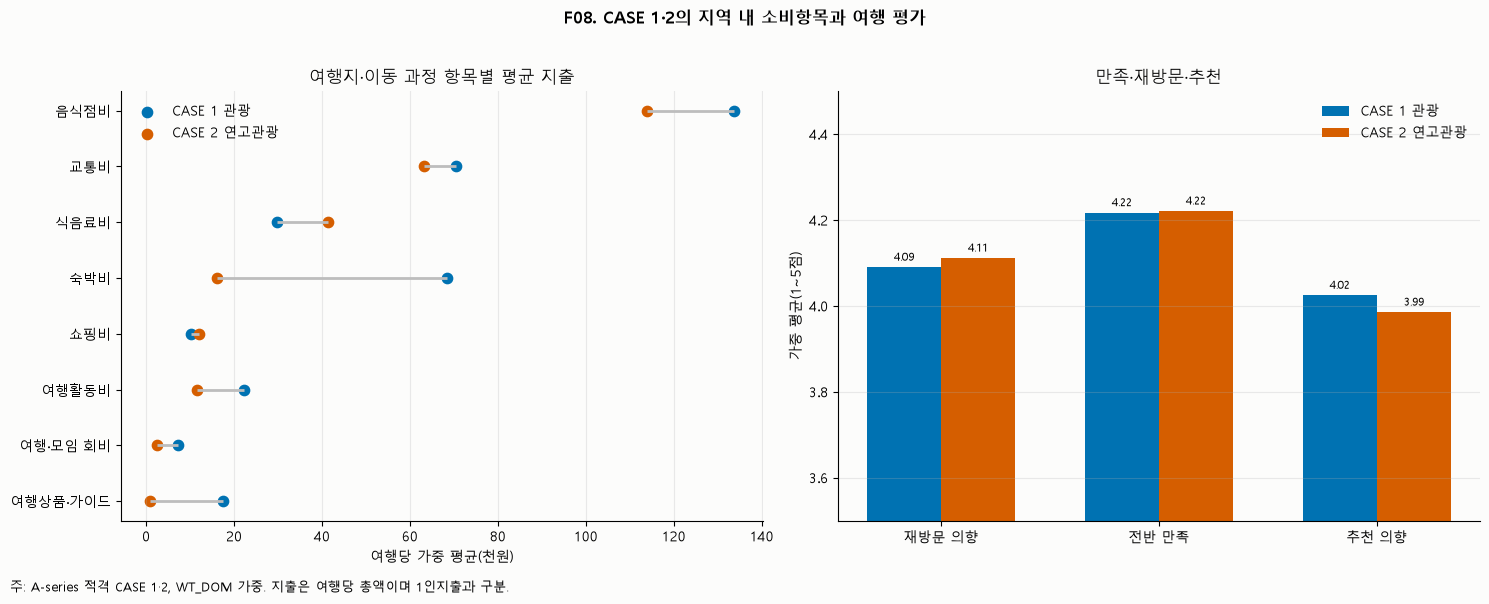

In [13]:
expense_columns = ["A8A", "A8B", "A8C", "A8D", "A8E", "A8F", "A8G", "A8H", "A8I", "A8J"]
expense_labels = {
    "A8A": "여행상품·가이드", "A8B": "여행·모임 회비", "A8C": "숙박비",
    "A8D": "음식점비", "A8E": "식음료비", "A8F": "교통비",
    "A8G": "여행활동비", "A8H": "쇼핑비", "A8I": "귀금속", "A8J": "기타",
}
expense_rows = []
outcome_rows = []
for case in (1, 2):
    group = a_analysis.loc[a_analysis["D_TRA1_CASE"].eq(case)]
    for column in expense_columns:
        result = weighted_mean_interval(group, column)
        result["group"] = CASE_LABELS[case]
        result["item"] = expense_labels[column]
        expense_rows.append(result)
    for column, label in [("A9", "전반 만족"), ("A10", "재방문 의향"), ("A11", "추천 의향")]:
        result = weighted_mean_interval(group, column)
        result["group"] = CASE_LABELS[case]
        result["outcome"] = label
        outcome_rows.append(result)
expense_table = pd.DataFrame(expense_rows).set_index(["group", "item"])
outcome_table = pd.DataFrame(outcome_rows).set_index(["group", "outcome"])

pure_rows = []
for case, mask in [(1, pure_type_1), (2, pure_type_2)]:
    group = a_analysis.loc[mask]
    for variable in ("NA8", "A9", "A10", "A11"):
        pure_rows.append({
            "group": CASE_LABELS[case],
            "variable": variable,
            "N": len(group),
            "weighted_mean": weighted_mean(group[variable], group["WT_DOM"]),
            "N_eff": effective_n(group["WT_DOM"]),
        })
pure_sensitivity = pd.DataFrame(pure_rows).set_index(["group", "variable"])

detail_rows = []
for case in (1, 2):
    group = a_analysis.loc[a_analysis["D_TRA1_CASE"].eq(case)].copy()
    for column in [f"A9A_{index}" for index in range(1, 13)] + [f"A12_{index}" for index in range(1, 7)]:
        values = group[column].replace(9, np.nan)
        label = meta.column_names_to_labels[column].split(")", maxsplit=1)[-1].strip()
        detail_rows.append({
            "group": CASE_LABELS[case], "variable": column, "item": label,
            "N": int(values.notna().sum()), "missing_or_not_applicable_N": int(values.isna().sum()),
            "weighted_denominator": group.loc[values.notna(), "WT_DOM"].sum(),
            "N_eff": effective_n(group.loc[values.notna(), "WT_DOM"]),
            "weighted_mean": weighted_mean(values, group["WT_DOM"]),
        })
detail_rating_table = pd.DataFrame(detail_rows).set_index(["group", "variable"])
display(
    expense_table.round(1), outcome_table.round(2), pure_sensitivity.round(2),
    detail_rating_table.round(2),
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
expense_pivot = expense_table["mean"].unstack("group") / 1000
expense_focus = expense_pivot.max(axis=1).nlargest(8).index
expense_plot = expense_pivot.loc[expense_focus].sort_values(CASE_LABELS[2])
y = np.arange(len(expense_plot))
axes[0].hlines(y, expense_plot[CASE_LABELS[1]], expense_plot[CASE_LABELS[2]], color="#BDBDBD", linewidth=2)
axes[0].scatter(expense_plot[CASE_LABELS[1]], y, color=CASE_COLORS[1], s=55, label=short_case_label(1))
axes[0].scatter(expense_plot[CASE_LABELS[2]], y, color=CASE_COLORS[2], s=55, label=short_case_label(2))
axes[0].set(title="여행지·이동 과정 항목별 평균 지출", xlabel="여행당 가중 평균(천원)", yticks=y, yticklabels=expense_plot.index)
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(frameon=False)

outcome_pivot = outcome_table["mean"].unstack("group")
x = np.arange(len(outcome_pivot))
width = 0.34
axes[1].bar(x - width / 2, outcome_pivot[CASE_LABELS[1]], width, color=CASE_COLORS[1], label=short_case_label(1))
axes[1].bar(x + width / 2, outcome_pivot[CASE_LABELS[2]], width, color=CASE_COLORS[2], label=short_case_label(2))
axes[1].set(title="만족·재방문·추천", ylabel="가중 평균(1~5점)", xticks=x, xticklabels=outcome_pivot.index, ylim=(3.5, 4.5))
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.25)
add_value_labels(axes[1], decimals=2)
fig.suptitle("F08. CASE 1·2의 지역 내 소비항목과 여행 평가", fontweight="bold")
fig.text(0.01, 0.01, "주: A-series 적격 CASE 1·2, WT_DOM 가중. 지출은 여행당 총액이며 1인지출과 구분.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
plt.show()

A5A는 A5에서 인터넷·웹사이트를 선택한 응답자만의 조건부 분포이며, 전체 A-series 표본의
분포가 아니다. A4는 다중응답 선택률로, 각 활동의 분모는 적격 CASE 1 또는 CASE 2의 가중합이다.
순수유형 표본은 민감도 분석용이며 주 분석은 모든 적격 CASE 1·2를 사용한다.

## 5. 지역·인구감소지역·연령·동반·계절성

N  missing_N  \
group            indicator                                 
CASE 1 관광·휴양     is_capital_region    20206.0        0.0   
                 is_declining_region  20206.0        0.0   
CASE 2 관광결합 연고방문 is_capital_region     3977.0        0.0   
                 is_declining_region   3977.0        0.0   
CASE 3 단순 연고방문   is_capital_region     2902.0        0.0   
                 is_declining_region   2902.0        0.0   

                                      weighted_denominator  percent     N_eff  \
group            indicator                                                      
CASE 1 관광·휴양     is_capital_region            2.172865e+08    29.14  14131.12   
                 is_declining_region          2.172865e+08    35.99  14131.12   
CASE 2 관광결합 연고방문 is_capital_region            3.752542e+07    19.72   2711.10   
                 is_declining_region          3.752542e+07    34.10   2711.10   
CASE 3 단순 연고방문   is_capital_region            3.235101e+07    42.84   2062.42   
                 is_declining_region          3.235101e+07    24.95   2062.42   

                                      ci_low  ci_high  
group            indicator                             
CASE 1 관광·휴양     is_capital_region     28.39    29.89  
                 is_declining_region   35.20    36.78  
CASE 2 관광결합 연고방문 is_capital_region     18.23    21.22  
                 is_declining_region   32.32    35.89  
CASE 3 단순 연고방문   is_capital_region     40.71    44.98  
                 is_declining_region   23.08    26.81

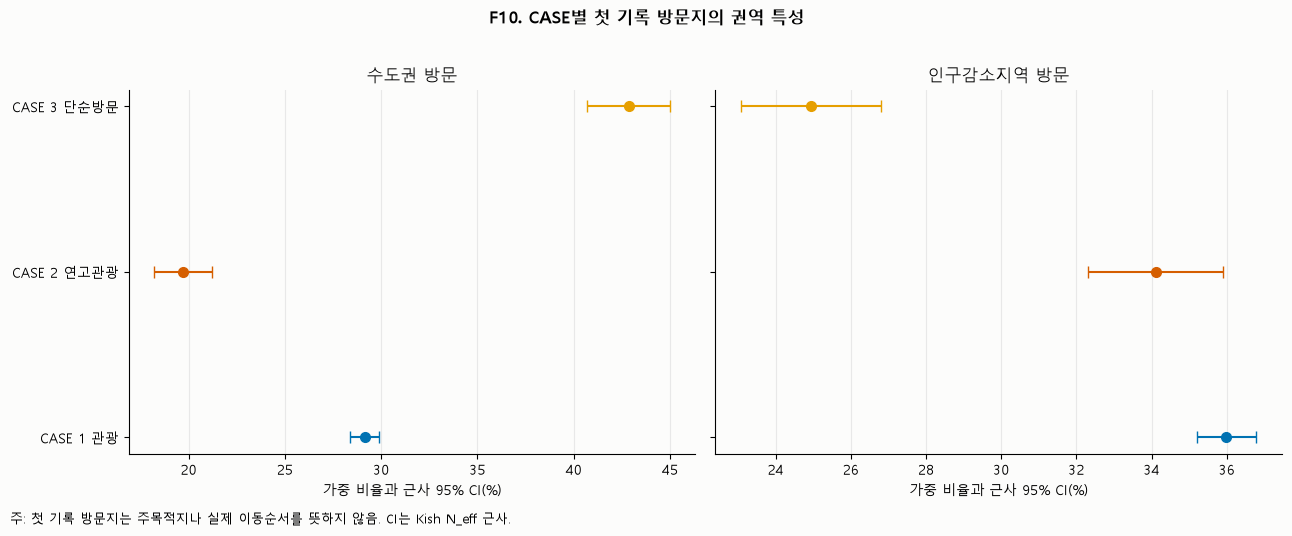

In [14]:
sido_abbreviation = {
    "서울특별시": "서울", "부산광역시": "부산", "대구광역시": "대구",
    "인천광역시": "인천", "광주광역시": "광주", "대전광역시": "대전",
    "울산광역시": "울산", "세종특별자치시": "세종", "경기도": "경기",
    "강원도": "강원", "강원특별자치도": "강원", "충청북도": "충북",
    "충청남도": "충남", "전라북도": "전북", "전북특별자치도": "전북",
    "전라남도": "전남", "경상북도": "경북", "경상남도": "경남",
    "제주특별자치도": "제주",
}
declining_regions = pd.read_csv(DECLINE_PATH, encoding="utf-8-sig")
declining_keys = set(zip(declining_regions["sido"], declining_regions["sigungu"]))

first_visits["sido_short"] = first_visits["시도명"].map(sido_abbreviation)
first_visits["is_capital_region"] = first_visits["sido_short"].isin(["서울", "인천", "경기"])
first_visits["is_declining_region"] = [
    (sido, sigungu) in declining_keys
    for sido, sigungu in zip(first_visits["sido_short"], first_visits["시군구명"])
]
assert first_visits["sido_short"].notna().all()

location_rows = []
for case in (1, 2, 3):
    group = first_visits.loc[first_visits["CASE"].eq(case)]
    for indicator in ("is_capital_region", "is_declining_region"):
        summary = weighted_binary_summary(group, indicator)
        summary["group"] = CASE_LABELS[case]
        summary["indicator"] = indicator
        location_rows.append(summary)
location_summary = pd.DataFrame(location_rows).set_index(["group", "indicator"])
display(location_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3), sharey=True)
for axis, indicator, title in [
    (axes[0], "is_capital_region", "수도권 방문"),
    (axes[1], "is_declining_region", "인구감소지역 방문"),
]:
    for y_pos, case in enumerate((1, 2, 3)):
        row = location_summary.loc[(CASE_LABELS[case], indicator)]
        axis.errorbar(
            row["percent"], y_pos,
            xerr=[[row["percent"] - row["ci_low"]], [row["ci_high"] - row["percent"]]],
            fmt="o", color=CASE_COLORS[case], capsize=4, markersize=7,
        )
    axis.set(title=title, xlabel="가중 비율과 근사 95% CI(%)", yticks=range(3), yticklabels=[short_case_label(case) for case in (1, 2, 3)])
    axis.grid(axis="x", alpha=0.25)
fig.suptitle("F10. CASE별 첫 기록 방문지의 권역 특성", fontweight="bold")
fig.text(0.01, 0.01, "주: 첫 기록 방문지는 주목적지나 실제 이동순서를 뜻하지 않음. CI는 Kish N_eff 근사.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 0.96))
plt.show()

,N_all,weighted_denominator_all,relationship_visit_pct,N_relationship,weighted_denominator_relationship,tourism_combination_pct,weighted_ONE_COST_CASE2,weighted_ONE_COST_CASE3
age,,,,,,,,
15~19세,867,9287978.2,29.3,254,2718716.1,52.2,90043.8,60610.5
20대,3892,42972559.6,15.8,703,6805688.9,52.5,112865.1,67292.4
30대,4938,54639631.0,19.7,1046,10736888.4,55.0,122856.8,81626.4
40대,5679,59954385.7,25.1,1437,15033873.8,52.9,113346.8,74662.8
50대,6254,60604122.0,24.3,1540,14697709.0,54.5,126382.2,73487.4
60대,4660,48030231.6,24.9,1168,11935642.3,53.4,112810.2,76501.5
70세이상,2274,25420399.2,31.3,731,7947912.6,53.9,101457.3,64636.6


N  weighted_relationship_pct   N_eff
BAGE   is_declining_region                                           
15~19세 False                 598.0                       26.8   420.8
       True                  269.0                       35.8   172.1
20대    False                2682.0                       16.5  1788.5
       True                 1210.0                       14.1   785.9
30대    False                3351.0                       20.4  2357.2
       True                 1587.0                       17.9  1094.7
40대    False                3542.0                       26.4  2594.8
       True                 2137.0                       22.6  1522.3
50대    False                3691.0                       26.1  2688.0
       True                 2563.0                       21.1  1800.3
60대    False                2733.0                       27.7  1935.4
       True                 1927.0                       20.3  1387.2
70세이상  False                1377.0                       35.3   915.0
       True                  897.0                       24.0   567.9

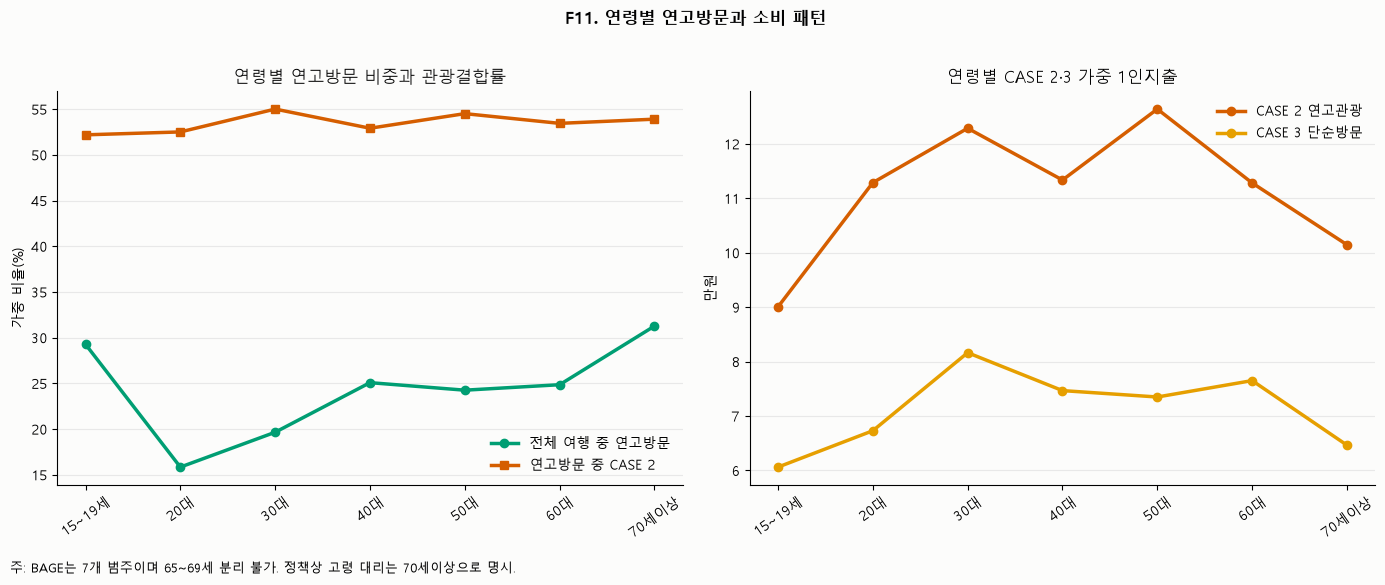

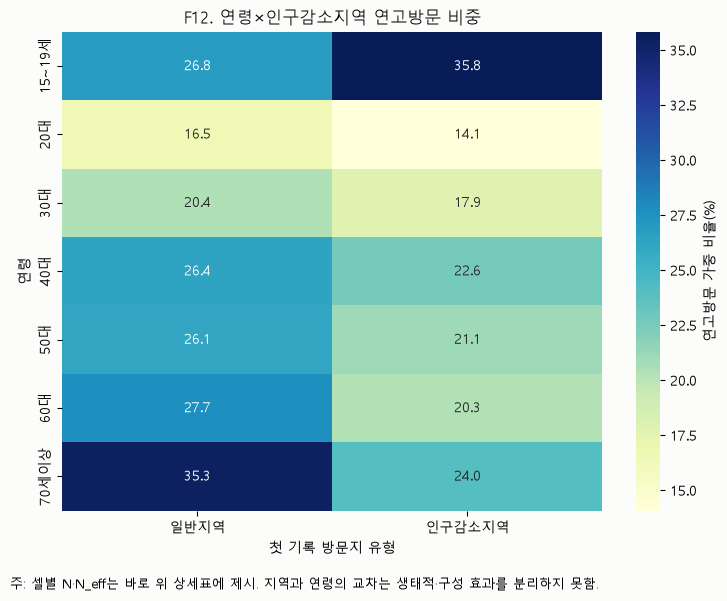

In [15]:
age_data = trips_long.dropna(subset=["BAGE"]).copy()
age_rows = []
for age_code, group in age_data.groupby("BAGE"):
    yeongo = group.loc[group["is_yeongo"]]
    age_rows.append({
        "age": age_labels[age_code],
        "N_all": len(group),
        "weighted_denominator_all": group["WT_DOM"].sum(),
        "relationship_visit_pct": weighted_mean(group["is_yeongo"], group["WT_DOM"]) * 100,
        "N_relationship": len(yeongo),
        "weighted_denominator_relationship": yeongo["WT_DOM"].sum(),
        "tourism_combination_pct": weighted_mean(
            yeongo["is_combined_yeongo"], yeongo["WT_DOM"]
        ) * 100,
        "weighted_ONE_COST_CASE2": weighted_mean(
            group.loc[group["CASE"].eq(2), "ONE_COST"],
            group.loc[group["CASE"].eq(2), "WT_DOM"],
        ),
        "weighted_ONE_COST_CASE3": weighted_mean(
            group.loc[group["CASE"].eq(3), "ONE_COST"],
            group.loc[group["CASE"].eq(3), "WT_DOM"],
        ),
    })
age_table = pd.DataFrame(age_rows).set_index("age")
assert age_table.index.tolist() == [age_labels[key] for key in sorted(age_labels)]

age_distribution = age_data.groupby(["CASE", "BAGE"])["WT_DOM"].sum().unstack(fill_value=0)
age_distribution = age_distribution.div(age_distribution.sum(axis=1), axis=0) * 100
assert np.allclose(age_distribution.sum(axis=1), 100, atol=1e-6)

first_with_age = first_visits.merge(
    trips_long[["ID", "TRIP_NO", "BAGE"]],
    on=["ID", "TRIP_NO"],
    how="left",
    validate="one_to_one",
)
age_region = first_with_age.dropna(subset=["BAGE"]).groupby(
    ["BAGE", "is_declining_region"]
).apply(
    lambda group: pd.Series({
        "N": len(group),
        "weighted_relationship_pct": weighted_mean(
            group["CASE"].isin([2, 3]), group["WT_DOM"]
        ) * 100,
        "N_eff": effective_n(group["WT_DOM"]),
    }),
    include_groups=False,
)
age_region = age_region.rename(index=age_labels, level="BAGE")
display(age_table.round(1), age_region.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
age_order = age_table.index.tolist()
axes[0].plot(age_order, age_table["relationship_visit_pct"], marker="o", color="#009E73", linewidth=2.5)
axes[0].plot(age_order, age_table["tourism_combination_pct"], marker="s", color=CASE_COLORS[2], linewidth=2.5)
axes[0].set(title="연령별 연고방문 비중과 관광결합률", ylabel="가중 비율(%)")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(["전체 여행 중 연고방문", "연고방문 중 CASE 2"], frameon=False)
axes[0].grid(axis="y", alpha=0.25)
axes[1].plot(age_order, age_table["weighted_ONE_COST_CASE2"] / 10000, marker="o", color=CASE_COLORS[2], linewidth=2.5, label=short_case_label(2))
axes[1].plot(age_order, age_table["weighted_ONE_COST_CASE3"] / 10000, marker="o", color=CASE_COLORS[3], linewidth=2.5, label=short_case_label(3))
axes[1].set(title="연령별 CASE 2·3 가중 1인지출", ylabel="만원")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.25)
fig.suptitle("F11. 연령별 연고방문과 소비 패턴", fontweight="bold")
fig.text(0.01, 0.01, "주: BAGE는 7개 범주이며 65~69세 분리 불가. 정책상 고령 대리는 70세이상으로 명시.", fontsize=9)
plt.tight_layout(rect=(0, 0.04, 1, 0.96))
plt.show()

age_region_plot = age_region["weighted_relationship_pct"].unstack("is_declining_region")
age_region_plot.columns = ["일반지역", "인구감소지역"]
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(age_region_plot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "연고방문 가중 비율(%)"}, ax=ax)
ax.set(title="F12. 연령×인구감소지역 연고방문 비중", xlabel="첫 기록 방문지 유형", ylabel="연령")
fig.text(0.01, 0.01, "주: 셀별 N·N_eff는 바로 위 상세표에 제시. 지역과 연령의 교차는 생태적·구성 효과를 분리하지 못함.", fontsize=9)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

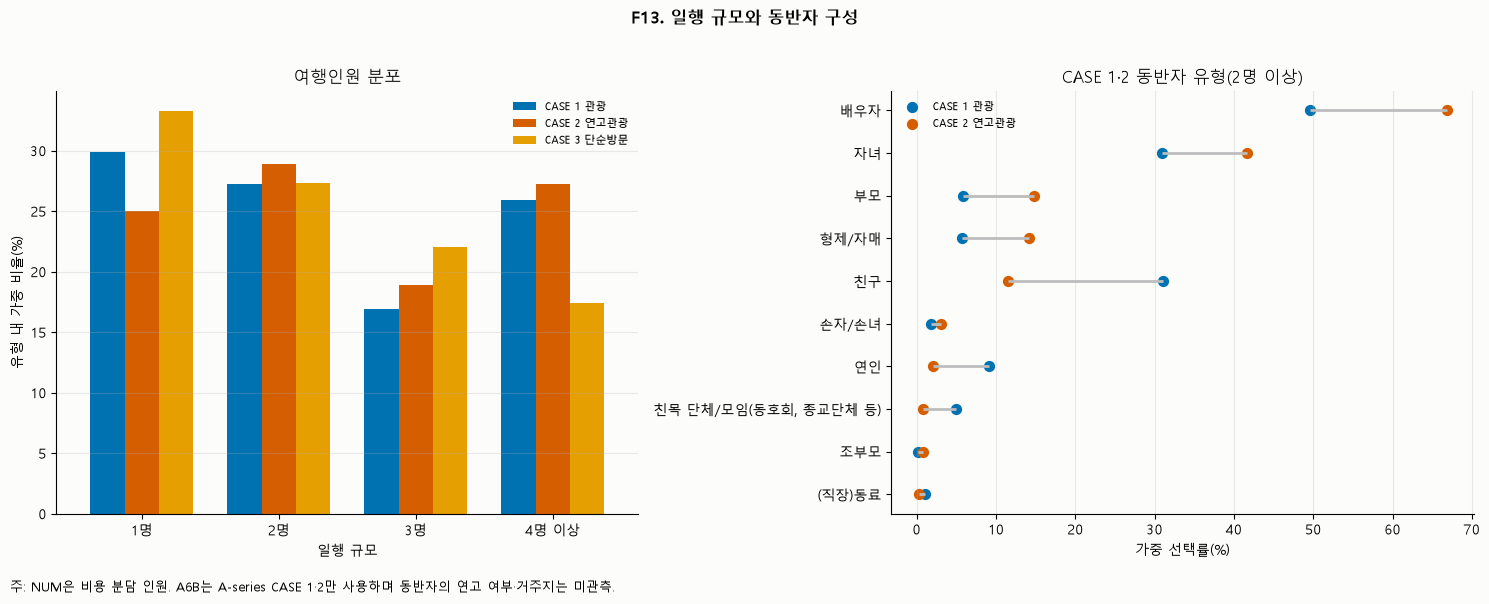

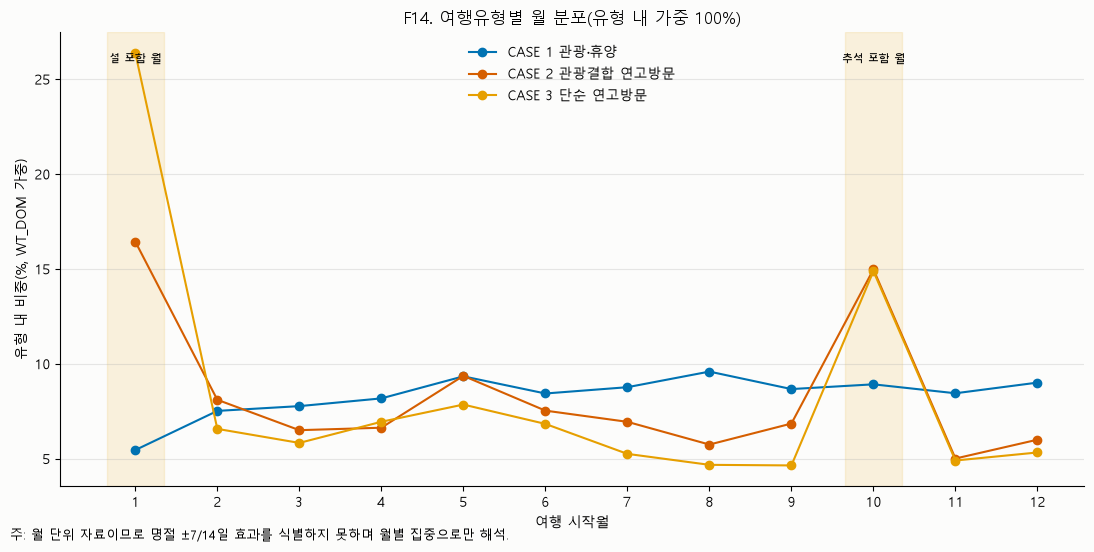

,N,missing_N,weighted_denominator,mean,N_eff,ci_low,ci_high
group,,,,,,,
CASE 1 관광·휴양,20206.0,0.0,2.172865e+08,2.54,14131.12,2.51,2.57
CASE 2 관광결합 연고방문,3977.0,0.0,3.752542e+07,2.58,2711.10,2.53,2.63
CASE 3 단순 연고방문,2902.0,0.0,3.235101e+07,2.26,2062.42,2.21,2.30


,group,party_band,N,weighted_denominator,weighted_pct
0,CASE 1 관광·휴양,1명,6377,217286531.0,29.9
1,CASE 1 관광·휴양,2명,5613,217286531.0,27.3
2,CASE 1 관광·휴양,3명,3222,217286531.0,16.9
3,CASE 1 관광·휴양,4명 이상,4994,217286531.0,25.9
4,CASE 2 관광결합 연고방문,1명,1139,37525420.5,25.0
5,CASE 2 관광결합 연고방문,2명,1152,37525420.5,28.9
6,CASE 2 관광결합 연고방문,3명,718,37525420.5,18.9
7,CASE 2 관광결합 연고방문,4명 이상,968,37525420.5,27.3
8,CASE 3 단순 연고방문,1명,1138,32351010.5,33.2
9,CASE 3 단순 연고방문,2명,767,32351010.5,27.3


,group,code,response,N,missing_or_unselected_N,weighted_denominator,N_eff,weighted_selection_pct
0,CASE 1 관광·휴양,1,배우자,18619,9971,201502491.8,13063.9,49.6
1,CASE 1 관광·휴양,2,자녀,18619,13408,201502491.8,13063.9,30.9
2,CASE 1 관광·휴양,3,손자/손녀,18619,18270,201502491.8,13063.9,1.9
3,CASE 1 관광·휴양,4,부모,18619,17642,201502491.8,13063.9,5.8
4,CASE 1 관광·휴양,5,조부모,18619,18587,201502491.8,13063.9,0.1
5,CASE 1 관광·휴양,6,형제/자매,18619,17604,201502491.8,13063.9,5.8
6,CASE 1 관광·휴양,7,친구,18619,12656,201502491.8,13063.9,31.1
7,CASE 1 관광·휴양,8,연인,18619,16749,201502491.8,13063.9,9.1
8,CASE 1 관광·휴양,9,(직장)동료,18619,18388,201502491.8,13063.9,1.1
9,CASE 1 관광·휴양,10,"친목 단체/모임(동호회, 종교단체 등)",18619,17586,201502491.8,13063.9,5.0


CASE,1,2,3
SMONTH,,,
1.0,5.45,16.43,26.37
2.0,7.51,8.10,6.56
3.0,7.76,6.49,5.82
4.0,8.17,6.62,6.94
5.0,9.33,9.36,7.84
6.0,8.43,7.52,6.83
7.0,8.76,6.93,5.25
8.0,9.58,5.74,4.67
9.0,8.66,6.84,4.64



**결과 해석.** 가중 평균 여행인원은 CASE 2 **2.58명**,
CASE 3 **2.26명**이다. 더 큰 일행은 관계인이 주변인을
데려오는 앵커 가설과 양립하지만, 동반자의 연고 여부와 출발지가 없으므로 확산효과를 증명하지 않는다.
1월·10월 집중도 역시 설·추석이 포함된 월의 패턴일 뿐 명절 인과효과가 아니다.


In [16]:
companion_rows = []
for case in (1, 2, 3):
    group = trips_long.loc[trips_long["CASE"].eq(case)]
    summary = weighted_mean_interval(group, "NUM")
    summary["group"] = CASE_LABELS[case]
    companion_rows.append(summary)
companion_summary = pd.DataFrame(companion_rows).set_index("group")

party_rows = []
for case in (1, 2, 3):
    group = trips_long.loc[trips_long["CASE"].eq(case)].copy()
    group["party_band"] = pd.cut(
        group["NUM"], bins=[0, 1, 2, 3, np.inf], labels=["1명", "2명", "3명", "4명 이상"]
    )
    denominator = group["WT_DOM"].sum()
    for party_band, frame in group.groupby("party_band", observed=True):
        party_rows.append({
            "group": CASE_LABELS[case], "party_band": party_band,
            "N": len(frame), "weighted_denominator": denominator,
            "weighted_pct": frame["WT_DOM"].sum() / denominator * 100,
        })
party_distribution = pd.DataFrame(party_rows)
companion_columns = sorted(
    [column for column in df.columns if column.startswith("A6B_")], key=slot_order
)
companion_type_table = weighted_multiselect_table(
    a_analysis.loc[a_analysis["A6"].ge(2)], companion_columns, "A6B_1"
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
party_pivot = party_distribution.pivot(index="party_band", columns="group", values="weighted_pct")
party_pivot.plot(
    kind="bar", ax=axes[0], color=[CASE_COLORS[case] for case in (1, 2, 3)], width=0.75
)
axes[0].set(title="여행인원 분포", xlabel="일행 규모", ylabel="유형 내 가중 비율(%)")
axes[0].legend([short_case_label(case) for case in (1, 2, 3)], frameon=False, fontsize=8)
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.25)

companion_pivot = companion_type_table.pivot(index="response", columns="group", values="weighted_selection_pct")
focus = companion_pivot.max(axis=1).nlargest(10).index
companion_plot = companion_pivot.loc[focus].sort_values(CASE_LABELS[2])
y = np.arange(len(companion_plot))
axes[1].hlines(y, companion_plot[CASE_LABELS[1]], companion_plot[CASE_LABELS[2]], color="#BDBDBD", linewidth=2)
axes[1].scatter(companion_plot[CASE_LABELS[1]], y, color=CASE_COLORS[1], s=50, label=short_case_label(1))
axes[1].scatter(companion_plot[CASE_LABELS[2]], y, color=CASE_COLORS[2], s=50, label=short_case_label(2))
axes[1].set(title="CASE 1·2 동반자 유형(2명 이상)", xlabel="가중 선택률(%)", yticks=y, yticklabels=companion_plot.index)
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(axis="x", alpha=0.25)
fig.suptitle("F13. 일행 규모와 동반자 구성", fontweight="bold")
fig.text(0.01, 0.01, "주: NUM은 비용 분담 인원. A6B는 A-series CASE 1·2만 사용하며 동반자의 연고 여부·거주지는 미관측.", fontsize=9)
plt.tight_layout(rect=(0, 0.04, 1, 0.96))
plt.show()

monthly = trips_long.loc[trips_long["CASE"].isin([1, 2, 3])].groupby(
    ["SMONTH", "CASE"]
)["WT_DOM"].sum().unstack(fill_value=0)
monthly_share = monthly.div(monthly.sum(axis=0), axis=1) * 100
assert np.allclose(monthly_share.sum(axis=0), 100, atol=1e-6)

fig, ax = plt.subplots(figsize=(11, 5.5))
for case in (1, 2, 3):
    ax.plot(
        monthly_share.index,
        monthly_share[case],
        color=CASE_COLORS[case],
        marker="o",
        label=CASE_LABELS[case],
    )
ax.set(
    title="F14. 여행유형별 월 분포(유형 내 가중 100%)",
    xlabel="여행 시작월",
    ylabel="유형 내 비중(%, WT_DOM 가중)",
    xticks=range(1, 13),
)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
for month, label in [(1, "설 포함 월"), (10, "추석 포함 월")]:
    ax.axvspan(month - 0.35, month + 0.35, color="#E69F00", alpha=0.12)
    ax.text(month, ax.get_ylim()[1] * 0.96, label, ha="center", va="top", fontsize=8)
fig.text(0.01, 0.01, "주: 월 단위 자료이므로 명절 ±7/14일 효과를 식별하지 못하며 월별 집중으로만 해석.", fontsize=9)
plt.tight_layout()
plt.show()

display(companion_summary.round(2), party_distribution.round(1), companion_type_table.round(1), monthly_share.round(2))

display(Markdown(f"""
**결과 해석.** 가중 평균 여행인원은 CASE 2 **{companion_summary.loc[CASE_LABELS[2], 'mean']:.2f}명**,
CASE 3 **{companion_summary.loc[CASE_LABELS[3], 'mean']:.2f}명**이다. 더 큰 일행은 관계인이 주변인을
데려오는 앵커 가설과 양립하지만, 동반자의 연고 여부와 출발지가 없으므로 확산효과를 증명하지 않는다.
1월·10월 집중도 역시 설·추석이 포함된 월의 패턴일 뿐 명절 인과효과가 아니다.
"""))

연령은 7개 범주뿐이므로 65~69세를 분리할 수 없다. 따라서 “65세 이상” 대신 `70세이상`을
명시적 대리로 사용한다. `NUM-1`은 비용 분담 인원 기준의 동반 대리이며 동반자의 연고 여부는
관측되지 않는다. 원자료에는 월만 있어 2025년 설·추석 ±7/14일 창을 식별할 수 없으므로,
월별 집중을 명절 효과로 단정하지 않는다.

## 6. 시군구 표본 안정성·축소추정

,value
regions,229
stable_regions_N_ge_50_and_N_eff_ge_30,164
masked_unstable_regions,65


,sido,sigungu,N,N_eff,weighted_dependency_pct,dependency_ci_low,dependency_ci_high,shrunk_dependency_pct,relationship_N,relationship_N_eff,tourism_combination_pct,declining_region,stable
75,경북,상주시,65,48.1,51.5,37.4,65.6,37.1,30,21.0,50.6,True,True
206,충남,논산시,148,101.5,39.6,30.1,49.1,34.2,62,43.3,65.5,True,True
81,경북,영천시,71,56.5,39.9,27.1,52.6,32.1,27,20.3,56.7,True,True
54,경남,밀양시,233,174.8,33.8,26.8,40.9,31.5,75,53.9,69.1,True,True
200,전북,진안군,86,52.6,38.8,25.7,52.0,31.2,28,17.1,85.8,True,True
205,충남,금산군,112,76.3,36.4,25.6,47.2,31.2,35,21.8,62.4,True,True
185,전남,해남군,111,69.6,36.5,25.2,47.8,30.9,40,25.1,61.8,True,True
209,충남,부여군,182,123.3,32.9,24.6,41.2,30.1,61,38.0,72.1,True,True
179,전남,영암군,63,44.0,37.6,23.2,51.9,29.9,20,12.8,40.7,True,True
77,경북,안동시,185,140.6,31.9,24.2,39.6,29.6,52,40.7,67.9,True,True


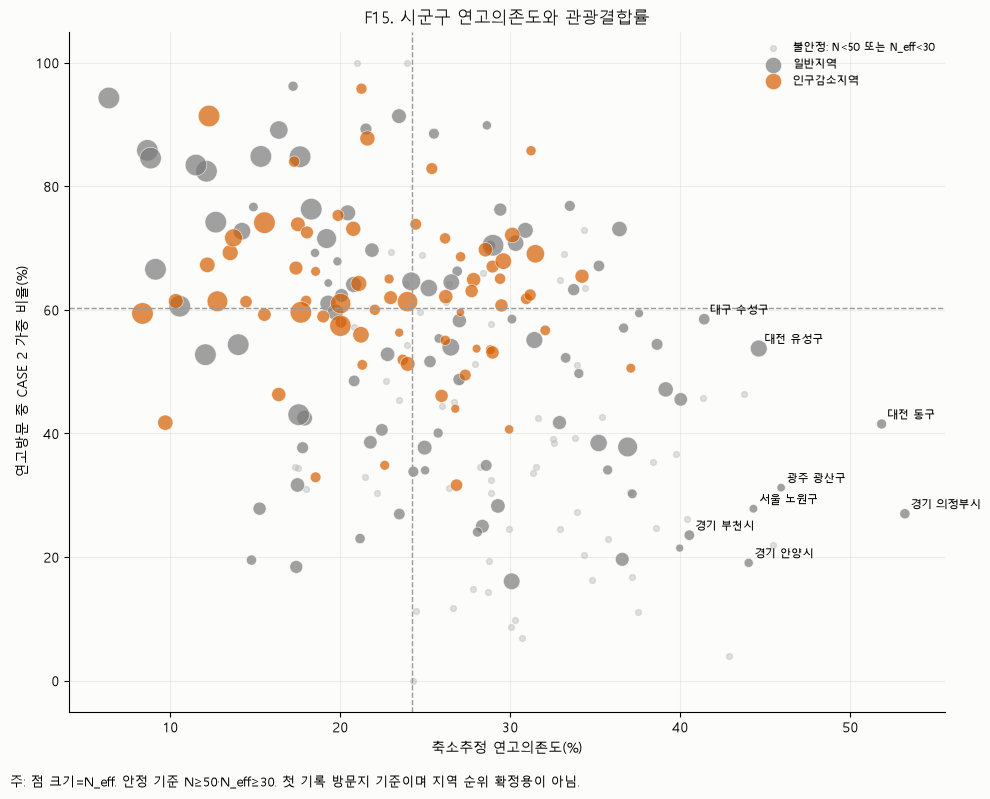

In [17]:
regional = first_visits.copy()
regional["is_yeongo"] = regional["CASE"].isin([2, 3])
regional["is_case2"] = regional["CASE"].eq(2)
overall_dependency = weighted_mean(regional["is_yeongo"], regional["WT_DOM"])
prior_strength = 50.0

regional_rows = []
for (sido, sigungu), group in regional.groupby(["sido_short", "시군구명"]):
    yeongo = group.loc[group["is_yeongo"]]
    n_eff_all = effective_n(group["WT_DOM"])
    dependency = weighted_mean(group["is_yeongo"], group["WT_DOM"])
    standard_error = np.sqrt(dependency * (1 - dependency) / n_eff_all)
    if len(yeongo):
        n_eff_yeongo = effective_n(yeongo["WT_DOM"])
        combination = weighted_mean(yeongo["is_case2"], yeongo["WT_DOM"])
    else:
        n_eff_yeongo = np.nan
        combination = np.nan
    shrunk_dependency = (
        n_eff_all * dependency + prior_strength * overall_dependency
    ) / (n_eff_all + prior_strength)
    regional_rows.append({
        "sido": sido,
        "sigungu": sigungu,
        "N": len(group),
        "N_eff": n_eff_all,
        "weighted_dependency_pct": dependency * 100,
        "dependency_ci_low": max(0, dependency - 1.96 * standard_error) * 100,
        "dependency_ci_high": min(1, dependency + 1.96 * standard_error) * 100,
        "shrunk_dependency_pct": shrunk_dependency * 100,
        "relationship_N": len(yeongo),
        "relationship_N_eff": n_eff_yeongo,
        "tourism_combination_pct": combination * 100,
        "declining_region": (sido, sigungu) in declining_keys,
    })
regional_table = pd.DataFrame(regional_rows)
regional_table["stable"] = regional_table["N"].ge(50) & regional_table["N_eff"].ge(30)
stable_candidates = regional_table.loc[regional_table["stable"]].sort_values(
    ["declining_region", "shrunk_dependency_pct"], ascending=[False, False]
)
display(
    pd.Series({
        "regions": len(regional_table),
        "stable_regions_N_ge_50_and_N_eff_ge_30": regional_table["stable"].sum(),
        "masked_unstable_regions": (~regional_table["stable"]).sum(),
    }).to_frame("value"),
    stable_candidates.head(20).round(1),
)

fig, ax = plt.subplots(figsize=(10, 8))
unstable = regional_table.loc[~regional_table["stable"]]
stable = regional_table.loc[regional_table["stable"]]
ax.scatter(
    unstable["shrunk_dependency_pct"], unstable["tourism_combination_pct"],
    s=18, color="#BDBDBD", alpha=0.45, label="불안정: N<50 또는 N_eff<30",
)
for decline, color, label in [(False, "#7A7A7A", "일반지역"), (True, CASE_COLORS[2], "인구감소지역")]:
    subset = stable.loc[stable["declining_region"].eq(decline)]
    ax.scatter(
        subset["shrunk_dependency_pct"], subset["tourism_combination_pct"],
        s=np.clip(subset["N_eff"], 25, 240), color=color, alpha=0.7,
        edgecolor="white", linewidth=0.5, label=label,
    )
label_candidates = stable.nlargest(8, "shrunk_dependency_pct")
for _, row in label_candidates.iterrows():
    ax.annotate(f"{row['sido']} {row['sigungu']}", (row["shrunk_dependency_pct"], row["tourism_combination_pct"]), xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.axvline(stable["shrunk_dependency_pct"].median(), color="#999999", linestyle="--", linewidth=1)
ax.axhline(stable["tourism_combination_pct"].median(), color="#999999", linestyle="--", linewidth=1)
ax.set(
    title="F15. 시군구 연고의존도와 관광결합률",
    xlabel="축소추정 연고의존도(%)",
    ylabel="연고방문 중 CASE 2 가중 비율(%)",
)
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.2)
fig.text(0.01, 0.01, "주: 점 크기=N_eff. 안정 기준 N≥50·N_eff≥30. 첫 기록 방문지 기준이며 지역 순위 확정용이 아님.", fontsize=9)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.show()

시군구 표는 첫 기록 방문지 기준이다. `N≥50`과 `N_eff≥30`을 동시에 만족하지 못한 지역은
순위에서 마스킹한다. 안정 지역도 관측된 집중도의 기술통계일 뿐이며, 축소추정값을 정책
우선순위나 인과효과로 바로 해석하지 않는다. 공간 경계·거리·인접성 자료가 없으므로 Moran/LISA,
입지최적화, OD 경로 분석은 이 통합 EDA에 포함하지 않는다.

## 7. ZQ1 보조 진단과 핵심 정책 요약

,N,weighted_count,weighted_pct
ZQ1_1,,,
시간이 없어서,879,9629950.8,39.3
"가족, 친구와 시간을 맞추기 힘들어서",431,4662597.1,19.0
최근에 여행을 다녀와서,265,2783038.8,11.3
여행에 관심이 없어서,157,1896202.0,7.7
여행 경비가 부족해서,126,1644012.1,6.7
함께 여행할 사람이 없어서,83,860168.2,3.5
건강상의 문제로,70,733834.5,3.0
집안에 돌봐야 하는 가족이 있어서,45,583578.8,2.4
여행이 재미없을 것 같아서,50,583466.6,2.4


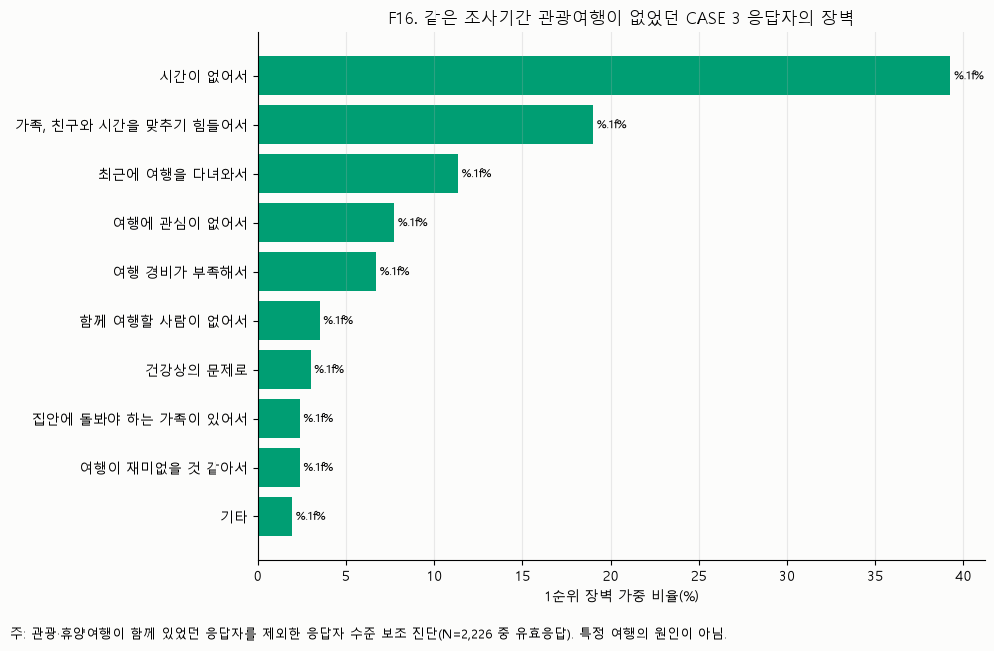

In [18]:
zq1_labels = var_labels(meta, "ZQ1_1")
zq1_case3 = zq1_clean.loc[zq1_clean["D_TRA1_CASE"].eq(3)]
zq1_valid = zq1_case3[["ZQ1_1", "WT_DOM"]].dropna()
zq1_table = zq1_valid.groupby("ZQ1_1").agg(
    N=("ZQ1_1", "size"),
    weighted_count=("WT_DOM", "sum"),
)
zq1_table["weighted_pct"] = (
    zq1_table["weighted_count"] / zq1_table["weighted_count"].sum() * 100
)
zq1_table.index = zq1_table.index.map(zq1_labels)
zq1_table = zq1_table.sort_values("weighted_pct", ascending=False)
display(zq1_table.round(1))

zq1_plot = zq1_table.head(10).sort_values("weighted_pct")
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(zq1_plot.index, zq1_plot["weighted_pct"], color="#009E73")
ax.set(
    title="F16. 같은 조사기간 관광여행이 없었던 CASE 3 응답자의 장벽",
    xlabel="1순위 장벽 가중 비율(%)",
    ylabel="",
)
ax.grid(axis="x", alpha=0.25)
add_value_labels(ax, decimals=1, suffix="%")
fig.text(0.01, 0.01, "주: 관광·휴양여행이 함께 있었던 응답자를 제외한 응답자 수준 보조 진단(N=2,226 중 유효응답). 특정 여행의 원인이 아님.", fontsize=9)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

In [19]:
case2_cost = spending_sensitivity.loc[(CASE_LABELS[2], "ONE_COST"), "mean"]
case3_cost = spending_sensitivity.loc[(CASE_LABELS[3], "ONE_COST"), "mean"]
case2_overnight = common_summary.loc[CASE_LABELS[2], "weighted_overnight_pct"]
case3_overnight = common_summary.loc[CASE_LABELS[3], "weighted_overnight_pct"]
top_barrier = zq1_table.index[0]

policy_summary = f"""
### 근거 기반 정책 요약

1. **문제 규모** — 전체 국내여행 중 연고방문(CASE 2+3)은 SA1 가중 기준
   **{relationship_share:.2f}%**다. 이는 무시하기 어려운 시장 규모이지만 고향·관계의 지속기간을
   직접 관측한 값은 아니다. 근거: `market_table`(응답자/조사회차, WT_DOM 가중).
2. **활동·소비 연결의 후보집단** — CASE 2와 CASE 3의 가중 1인 지출 평균은 각각
   **{case2_cost:,.0f}원**, **{case3_cost:,.0f}원**, 숙박률은 **{case2_overnight:.1f}%**와
   **{case3_overnight:.1f}%**다. 이는 횡단면 차이이며 CASE 3을 CASE 2로 바꾸면 같은 크기의
   효과가 생긴다는 뜻이 아니다. 근거: `common_summary`, `spending_sensitivity`(여행, WT_DOM 가중).
3. **정책 메커니즘** — 관계인을 초대·안내 채널로 활용하되, CASE 1·2에서 관측된 정보원과
   활동 선택률을 바탕으로 지역 식음·체험·유료 콘텐츠를 선택형으로 묶는다. ZQ1 상위 장벽
   `{top_barrier}`은 같은 기간 관광여행이 없었던 응답자의 보조 신호일 뿐 특정 CASE 3 여행의
   원인이 아니다.
4. **대상·전달경로** — 표본 안정 기준을 통과한 시군구에서 70세이상 대리집단과 CASE 3
   방문객을 우선 관찰하되, 친지·친구 추천코드, 지역 상점·교통·체험 예약 채널을 통해 전달한다.
   지역 순위는 `stable_candidates`의 N·N_eff·CI·축소추정과 함께만 사용한다.
5. **기대결과와 평가** — 지역 내 결제, 유료 체험, 숙박, 재방문을 별도로 기록하고 무작위 또는
   단계적 도입 비교를 사전 설계한다. 현 EDA만으로 정책 효과를 주장하지 않는다.
6. **핵심 위험** — CASE 2/3 비동질성, WT_DOM의 층화·PSU 부재, 첫 기록 방문지 한계,
   65~69세 식별 불가, 동반자의 연고 여부 미관측, 소지역 불안정성을 운영 설계에 반영한다.
"""
display(Markdown(policy_summary))

evidence_matrix = pd.DataFrame([
    {
        "판정": "확인된 결과", "질문": "연고방문 시장은 무시하기 어려운가?",
        "근거": f"가중 여행량의 {relationship_share:.2f}%", "근거_ID": "C-001 / F02",
        "허용 해석": "별도 정책 질문을 검토할 규모", "금지·한계": "고향·관계 지속기간 직접 식별 불가",
    },
    {
        "판정": "확인된 결과", "질문": "CASE 2·3의 지출 분포가 다른가?",
        "근거": f"가중 평균 차이 {raw_difference:,.0f}원; 민감도 방향 유지", "근거_ID": "C-003 / F04",
        "허용 해석": "여행유형 간 기술적 차이", "금지·한계": "전환효과·인과효과 아님",
    },
    {
        "판정": "불확실한 결과", "질문": "연고방문객이 주변인을 추가 유입하는가?",
        "근거": f"평균 일행 CASE2 {companion_summary.loc[CASE_LABELS[2], 'mean']:.2f}명, CASE3 {companion_summary.loc[CASE_LABELS[3], 'mean']:.2f}명",
        "근거_ID": "F13", "허용 해석": "앵커 가설의 대리 신호", "금지·한계": "동반자의 연고 여부·거주지 미관측",
    },
    {
        "판정": "추가 검증 필요", "질문": "명절·비수기 분산 정책이 효과적인가?",
        "근거": "1월·10월 월별 집중", "근거_ID": "F14",
        "허용 해석": "월 수준 수요 집중", "금지·한계": "일자 부재로 명절 효과 식별 불가",
    },
    {
        "판정": "추가 검증 필요", "질문": "어느 시군구를 우선 지원할 것인가?",
        "근거": f"229곳 중 안정 기준 통과 {int(regional_table['stable'].sum())}곳", "근거_ID": "F15",
        "허용 해석": "후보 탐색", "금지·한계": "표본·공간의존·정책비용 없이 순위 확정 금지",
    },
])
display(Markdown("### 종합 근거 매트릭스"), evidence_matrix)


### 근거 기반 정책 요약

1. **문제 규모** — 전체 국내여행 중 연고방문(CASE 2+3)은 SA1 가중 기준
   **23.22%**다. 이는 무시하기 어려운 시장 규모이지만 고향·관계의 지속기간을
   직접 관측한 값은 아니다. 근거: `market_table`(응답자/조사회차, WT_DOM 가중).
2. **활동·소비 연결의 후보집단** — CASE 2와 CASE 3의 가중 1인 지출 평균은 각각
   **115,251원**, **73,339원**, 숙박률은 **61.8%**와
   **41.5%**다. 이는 횡단면 차이이며 CASE 3을 CASE 2로 바꾸면 같은 크기의
   효과가 생긴다는 뜻이 아니다. 근거: `common_summary`, `spending_sensitivity`(여행, WT_DOM 가중).
3. **정책 메커니즘** — 관계인을 초대·안내 채널로 활용하되, CASE 1·2에서 관측된 정보원과
   활동 선택률을 바탕으로 지역 식음·체험·유료 콘텐츠를 선택형으로 묶는다. ZQ1 상위 장벽
   `시간이 없어서`은 같은 기간 관광여행이 없었던 응답자의 보조 신호일 뿐 특정 CASE 3 여행의
   원인이 아니다.
4. **대상·전달경로** — 표본 안정 기준을 통과한 시군구에서 70세이상 대리집단과 CASE 3
   방문객을 우선 관찰하되, 친지·친구 추천코드, 지역 상점·교통·체험 예약 채널을 통해 전달한다.
   지역 순위는 `stable_candidates`의 N·N_eff·CI·축소추정과 함께만 사용한다.
5. **기대결과와 평가** — 지역 내 결제, 유료 체험, 숙박, 재방문을 별도로 기록하고 무작위 또는
   단계적 도입 비교를 사전 설계한다. 현 EDA만으로 정책 효과를 주장하지 않는다.
6. **핵심 위험** — CASE 2/3 비동질성, WT_DOM의 층화·PSU 부재, 첫 기록 방문지 한계,
   65~69세 식별 불가, 동반자의 연고 여부 미관측, 소지역 불안정성을 운영 설계에 반영한다.


### 종합 근거 매트릭스

,판정,질문,근거,근거_ID,허용 해석,금지·한계
0,확인된 결과,연고방문 시장은 무시하기 어려운가?,가중 여행량의 23.22%,C-001 / F02,별도 정책 질문을 검토할 규모,고향·관계 지속기간 직접 식별 불가
1,확인된 결과,CASE 2·3의 지출 분포가 다른가?,"가중 평균 차이 41,912원; 민감도 방향 유지",C-003 / F04,여행유형 간 기술적 차이,전환효과·인과효과 아님
2,불확실한 결과,연고방문객이 주변인을 추가 유입하는가?,"평균 일행 CASE2 2.58명, CASE3 2.26명",F13,앵커 가설의 대리 신호,동반자의 연고 여부·거주지 미관측
3,추가 검증 필요,명절·비수기 분산 정책이 효과적인가?,1월·10월 월별 집중,F14,월 수준 수요 집중,일자 부재로 명절 효과 식별 불가
4,추가 검증 필요,어느 시군구를 우선 지원할 것인가?,229곳 중 안정 기준 통과 164곳,F15,후보 탐색,표본·공간의존·정책비용 없이 순위 확정 금지


## 8. 핵심 지표 계약 저장과 완료 검증

In [20]:
metrics = {
    "schema_version": 1,
    "seed": SEED,
    "inputs": input_register.to_dict(orient="records"),
    "units": {
        "respondents": {"key": ["ID"], "rows": len(df)},
        "trips_long": {"key": ["ID", "TRIP_NO"], "rows": len(trips_long)},
        "visits_long": {
            "key": ["ID", "TRIP_NO", "SPOT_NO"],
            "rows": len(visits_long),
        },
    },
    "branch_contract": {
        "a_series_analysis_cases": [1, 2],
        "case_3_a_series_use": "branch diagnostics only",
        "case_2_3_analysis_columns": core_columns,
        "zq1_raw_N": len(zq1_raw),
        "zq1_clean_N": len(zq1_clean),
        "zq1_clean_case_3_N": len(zq1_case3),
    },
    "validation": {
        "bage_labels_normalized": True,
        "a4_activity_labels_unique": activity_table["response"].nunique() == 21,
        "a4_activity_category_count": activity_table["response"].nunique(),
        "visit_mapping_failures": len(mapping_failures),
        "trip_key_duplicates": int(trips_long.duplicated(["ID", "TRIP_NO"]).sum()),
        "visit_key_duplicates": int(
            visits_long.duplicated(["ID", "TRIP_NO", "SPOT_NO"]).sum()
        ),
        "common_trip_completeness_pct": case_completeness.to_dict(),
    },
    "metrics": {
        "relationship_visit_share_pct": {
            "value": relationship_share,
            "unit": "percent",
            "population": "2025 국내여행 전체",
            "weighted": True,
            "analysis_unit": "respondent survey-wave travel counts",
            "method": "weighted total share",
            "formula": "sum(WT_DOM * (SA1_2 + SA1_3)) / sum(WT_DOM * SA1_1..5) * 100",
            "limitation": "Operational definition does not identify hometown or relationship duration.",
        },
        "case_2_weighted_one_cost_mean": {
            "value": case2_cost,
            "unit": "won per person",
            "population": "CASE 2 trips_long",
            "weighted": True,
            "analysis_unit": "trip",
            "method": "weighted descriptive mean with sensitivity specifications",
            "formula": "weighted mean of D_TRA*_ONE_COST using WT_DOM",
            "limitation": "Observational trip-type difference; not a policy effect.",
        },
        "case_3_weighted_one_cost_mean": {
            "value": case3_cost,
            "unit": "won per person",
            "population": "CASE 3 trips_long",
            "weighted": True,
            "analysis_unit": "trip",
            "method": "weighted descriptive mean with sensitivity specifications",
            "formula": "weighted mean of D_TRA*_ONE_COST using WT_DOM",
            "limitation": "Observational trip-type difference; not a policy effect.",
        },
        "case_2_overnight_pct": {
            "value": lodging_summary.loc[CASE_LABELS[2], "overnight_pct"],
            "unit": "percent", "population": "CASE 2 trips_long", "weighted": True,
            "analysis_unit": "trip", "method": "weighted binary share with Kish N_eff interval",
            "formula": "weighted mean(NIGHTS >= 1) * 100",
            "limitation": "Does not identify every lodging location across multiple destinations.",
        },
        "case_3_overnight_pct": {
            "value": lodging_summary.loc[CASE_LABELS[3], "overnight_pct"],
            "unit": "percent", "population": "CASE 3 trips_long", "weighted": True,
            "analysis_unit": "trip", "method": "weighted binary share with Kish N_eff interval",
            "formula": "weighted mean(NIGHTS >= 1) * 100",
            "limitation": "Does not identify every lodging location across multiple destinations.",
        },
        "case_2_mean_party_size": {
            "value": companion_summary.loc[CASE_LABELS[2], "mean"],
            "unit": "persons", "population": "CASE 2 trips_long", "weighted": True,
            "analysis_unit": "trip", "method": "weighted mean with Kish N_eff interval",
            "formula": "weighted mean(D_TRA*_NUM)",
            "limitation": "Companions' relationship status and residence are unobserved.",
        },
        "stable_sigungu_count": {
            "value": int(regional_table["stable"].sum()),
            "unit": "regions", "population": "first recorded destinations by sigungu", "weighted": False,
            "analysis_unit": "sigungu", "method": "count satisfying N >= 50 and N_eff >= 30",
            "formula": "sum(N >= 50 and Kish N_eff >= 30)",
            "limitation": "First recorded destination is not necessarily the primary destination.",
        },
    },
    "figures": [f"F{index:02d}" for index in range(1, 17)],
    "limitations": [
        "No strata or PSU variables were found; intervals use Kish N_eff approximations.",
        "CASE 2 and CASE 3 are observationally different trip types, not policy states.",
        "The first recorded destination is not asserted to be the primary destination.",
        "BAGE cannot identify ages 65-69 separately; age 70+ is an explicit proxy.",
    ],
}


assert metrics["units"]["trips_long"]["rows"] == 28564
assert metrics["units"]["respondents"]["rows"] == 52185
assert metrics["validation"]["trip_key_duplicates"] == 0
assert metrics["validation"]["visit_key_duplicates"] == 0
assert metrics["validation"]["visit_mapping_failures"] == 0
assert metrics["branch_contract"]["a_series_analysis_cases"] == [1, 2]
assert metrics["validation"]["a4_activity_labels_unique"]
assert len(metrics["figures"]) == 16

print("모든 구조·가중치·분기·라벨·지역 매핑 assert 통과")

metrics

모든 구조·가중치·분기·라벨·지역 매핑 assert 통과


{'schema_version': 1,
 'seed': 20260713,
 'inputs': [{'file': 'data\\raw\\national_travel_survey\\y2025\\2025년_국민여행조사_국내여행.SAV',
   'modified': Timestamp('2026-07-19 19:29:06.330578327'),
   'sha256': 'e367c69415ee99171f2114e6fdcd28e50b440384f93a9ab0116c2c8bae556b9e'},
  {'file': 'data\\raw\\national_travel_survey\\y2025\\national_travel_survey_codebook_2025.csv',
   'modified': Timestamp('2026-07-10 14:04:11'),
   'sha256': 'd877caa999dd11f76694229237a1a85f682d750a6b07449c954bdab3d3f7b7a9'},
  {'file': 'data\\raw\\national_travel_survey\\national_travel_survey_region_code.csv',
   'modified': Timestamp('2026-07-10 14:04:10'),
   'sha256': 'da82de139b59683f29125801080d4cc462f278fa4bf8408f45dcee51344232b0'},
  {'file': 'data\\raw\\pop_decline_danger\\pop_decline_danger_region.csv',
   'modified': Timestamp('2026-07-10 14:04:10'),
   'sha256': '27483a801ca76eeab730e2b9101926531297824a676297e0344f5bf944ecd2cb'}],
 'units': {'respondents': {'key': ['ID'], 'rows': 52185},
  'trips_long': {'

### 분석 한계와 다음 단계

- 국민여행조사는 가족·친지·친구 방문을 포착하지만 고향, 관계의 지속기간, 초대 네트워크를
  직접 식별하지 않는다.
- WT_DOM은 적용했지만 층화·PSU 변수가 없어 완전한 조사설계 분산을 재현하지 못했다.
- 소지역 결과는 표본 안정성 마스크와 축소추정을 적용했어도 후보 탐색용이다.
- 다음 단계의 정책 효과 판단에는 추천·초대 식별자, 실제 결제·숙박·체험 로그, 정책 노출 이력,
  비교지역 또는 무작위/단계적 도입 설계가 필요하다.